# Iteración 10 — Deep Learning con Stacking: Exploración Sistemática

## Competencia de Clasificación Decenal de Textos Históricos en Español (1500-1889)

**Grupo 33 - 3334- E(x) = Éxito**
Curso Aprendizaje de Máquina 2026-10

---

## Introducción y Objetivo

Esta iteración parte de los resultados obtenidos en la Iteración 7, donde un blend manual entre el stacking clásico de TF-IDF y BETO mostró mejoras en validación local frente al uso de cualquiera de los dos modelos por separado. A pesar de ese hallazgo, ese experimento usó un holdout 80/20 simple, lo que limitaba la confiabilidad de las métricas. El objetivo de esta iteración es re-evaluar esa hipótesis de forma rigurosa: usar K-Fold 5 con predicciones Out-of-Fold (OOF) reales para determinar si los transformers aportan valor real cuando se combinan con el ancla clásica de caracteres.

El problema consiste en clasificar párrafos históricos en español hacia su década de origen, representada como los tres primeros dígitos del año (por ejemplo, 157 para textos escritos entre 1570 y 1579). El corpus abarca 39 clases posibles, con aproximadamente 31.400 ejemplos de entrenamiento y 3.490 ejemplos de evaluación. El desafío central es la evolución lingüística a lo largo de cuatro siglos: el vocabulario, la ortografía y las grafías cambian de forma gradual pero sistemática, y cerca del 50% del vocabulario del conjunto de evaluación no aparece en entrenamiento.

**Resultados públicos de referencia en Kaggle:**
- Iteración 4: 0.31518 (stacking clásico + ancla deep)
- Iteración 6: 0.31805 (correcciones conservadoras)
- Iteración 7 (validación local): blend 0.6 stack / 0.4 BETO mostró mejora clara

**Estructura del notebook:**

Los experimentos siguen este orden: primero se establece el ancla clásica con TF-IDF + SGD bajo K-Fold (replicando la base de la Iteración 7 pero con validación más sólida), luego se entrenan los transformers BETO y BERTIN con el mismo esquema de folds, y finalmente se entrena un meta-modelo LightGBM que combina las probabilidades OOF de los tres modelos. La evaluación compara todos los enfoques bajo la misma metodología para decidir qué incorporar en la iteración siguiente.

---

**Entorno de ejecución:** Google Colab Pro (NVIDIA A100 40 GB, 83.5 GB RAM)
**Fecha:** 2026-05-20


## 1. Configuración del Entorno

El notebook está diseñado para ejecutarse en Google Colab Pro con acceso a Google Drive. La siguiente sección monta el drive, verifica el hardware disponible, instala las dependencias necesarias y configura todas las rutas de trabajo.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

print("Google Drive montado en /content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado en /content/drive


### 1.2 Verificación de Hardware

Verificar la GPU disponible antes de definir los parámetros de entrenamiento, ya que el batch size y la precisión mixta dependen de la memoria VRAM y el tipo de acelerador.


In [ ]:
import psutil
import subprocess
import torch

ram_gb = psutil.virtual_memory().total / (1024**3)
print(f" RAM Total: {ram_gb:.1f} GB")

if torch.cuda.is_available():
 gpu_name = torch.cuda.get_device_name(0)
 gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
 print(f" GPU: {gpu_name}")
 print(f" GPU Memory: {gpu_memory:.1f} GB")

 !nvidia-smi
else:
 print(" WARNING: No GPU detected!")
 print(" Este notebook REQUIERE GPU. Ir a Runtime > Change runtime type > GPU")

disk = psutil.disk_usage('/content/drive')
disk_free_gb = disk.free / (1024**3)
print(f"\n Disco libre en Drive: {disk_free_gb:.1f} GB")

print("\n" + "="*60)
print("RESUMEN DE HARDWARE")
print("="*60)
print(f"RAM: {ram_gb:.1f} GB")
if torch.cuda.is_available():
 print(f"GPU: {gpu_name}")
 print(f"GPU Memory: {gpu_memory:.1f} GB")
print(f"Drive: {disk_free_gb:.1f} GB libre")
print("="*60)

if ram_gb < 50:
 print(f" RAM menor a la esperada: {ram_gb:.1f} GB. El notebook puede correr, pero con menor margen.")
else:
 print(" RAM suficiente")
assert torch.cuda.is_available(), " GPU requerida para este notebook"
if torch.cuda.is_available():
 assert gpu_memory >= 15, " GPU memory insuficiente (se requieren al menos 15GB)"

print("\n Hardware verificado")

💾 RAM Total: 83.5 GB
🎮 GPU: NVIDIA A100-SXM4-40GB
🎮 GPU Memory: 39.5 GB
Fri May 22 13:29:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |

### 1.3 Instalación de Dependencias

Las dependencias se gestionan desde un archivo `requirements-colab.txt` almacenado en Google Drive, lo que permite reproducir el entorno exacto en sesiones futuras sin reinstalar manualmente cada paquete.


In [ ]:
import subprocess
import sys
from pathlib import Path

REQUIREMENTS_PATH = Path("/content/drive/MyDrive/parte2-proyecto-ml-drive/requirements-colab.txt")
if not REQUIREMENTS_PATH.exists():
 raise FileNotFoundError(f"No se encontró requirements-colab.txt en: {REQUIREMENTS_PATH}")

print(f"Instalando dependencias desde: {REQUIREMENTS_PATH}")
print("Modo seguro Colab: --no-deps para no tocar torch/CUDA ni paquetes base del runtime")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "peft", "torchvision"], check=False)

print("\nAttempting to fix numpy.dtype size changed error...")
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "numpy"], check=False)
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "pandas"], check=False)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numpy", "pandas"])
print("Numpy and Pandas reinstalled.")

subprocess.check_call([
 sys.executable, "-m", "pip", "install",
 "--no-cache-dir", "--no-deps", "-q",
 "-r", str(REQUIREMENTS_PATH),
])

import importlib.metadata as importlib_metadata
for package_name in ["numpy", "pandas", "scipy", "scikit-learn", "transformers", "accelerate", "datasets", "sentencepiece", "lightgbm"]:
 print(f"{package_name}: {importlib_metadata.version(package_name)}")

print(f" Dependencias instaladas desde: {REQUIREMENTS_PATH}")
print("Si esta celda se ejecutó después de un error de import, reinicia el runtime y corre el notebook desde el inicio.")

Instalando dependencias desde: /content/drive/MyDrive/parte2-proyecto-ml-drive/requirements-colab.txt
Modo seguro Colab: --no-deps para no tocar torch/CUDA ni paquetes base del runtime

Attempting to fix numpy.dtype size changed error...
Numpy and Pandas reinstalled.
numpy: 1.26.4
pandas: 2.2.2
scipy: 1.13.1
scikit-learn: 1.5.2
transformers: 4.46.3
accelerate: 1.1.1
datasets: 3.1.0
sentencepiece: 0.2.0
lightgbm: 4.5.0
✅ Dependencias instaladas desde: /content/drive/MyDrive/parte2-proyecto-ml-drive/requirements-colab.txt
Si esta celda se ejecutó después de un error de import, reinicia el runtime y corre el notebook desde el inicio.


### 1.4 Imports y Configuración Global

Corrección de incompatibilidad entre versiones de `tokenizers` y `accelerate` antes de cargar el resto de las librerías. Esta incompatibilidad apareció al actualizar el entorno de Colab y genera errores silenciosos durante el entrenamiento de transformers si no se resuelve primero.


In [ ]:
import subprocess
import sys
print("Fixing transformers/tokenizers/accelerate version mismatch...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers", "tokenizers", "accelerate"])

import gc
import json
import os
import random
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

warnings.filterwarnings('ignore')
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
 accuracy_score, f1_score, mean_absolute_error,
 confusion_matrix, classification_report, log_loss
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
 AutoTokenizer,
 AutoModelForSequenceClassification,
 Trainer,
 TrainingArguments,
 EarlyStoppingCallback,
 set_seed as hf_set_seed
)

import lightgbm as lgb

import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 50)

print(" Imports completados")
print(f" PyTorch: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
 print(f" CUDA version: {torch.version.cuda}")

Fixing transformers/tokenizers/accelerate version mismatch...
✅ Imports completados
   PyTorch: 2.10.0+cu128
   CUDA available: True
   CUDA version: 12.8


### 1.5 Semillas para Reproducibilidad

Fijar la misma semilla en Python, NumPy, PyTorch y CUDA garantiza que los splits de K-Fold y la inicialización de los modelos sean idénticos entre ejecuciones. Esto es crítico para poder comparar iteraciones de forma honesta.


In [ ]:
SEED = 42

def set_all_seeds(seed=SEED):
 """Establecer semillas en todas las librerías para reproducibilidad."""
 random.seed(seed)
 np.random.seed(seed)
 torch.manual_seed(seed)
 torch.cuda.manual_seed_all(seed)
 os.environ['PYTHONHASHSEED'] = str(seed)

 hf_set_seed(seed)

 torch.backends.cudnn.deterministic = False
 torch.backends.cudnn.benchmark = True

set_all_seeds(SEED)
print(f" Semillas establecidas: {SEED}")
print(" Reproducibilidad: MEDIA-ALTA; rendimiento optimizado con cudnn.benchmark=True")

✅ Semillas establecidas: 42
   Reproducibilidad: MEDIA-ALTA; rendimiento optimizado con cudnn.benchmark=True


### 1.6 Rutas y Parámetros Globales

Centralizar la configuración en una sola sección permite modificar parámetros clave (número de folds, longitud máxima de secuencia, batch size) sin buscarlos dispersos en el código. Los directorios de salida están organizados por tipo de artefacto para facilitar la reutilización de predicciones OOF entre iteraciones.

La configuración principal usa 5 folds estratificados, batch size adaptativo según la GPU disponible, y precisión mixta BF16 en A100 o FP16 en tarjetas más antiguas.


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/parte2-proyecto-ml-drive")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "iteracion_10_outputs"
TRAIN_PATH = DATA_DIR / "train.csv"
EVAL_PATH = DATA_DIR / "eval.csv"
ANCHOR_PATH = PROJECT_DIR / "submission_iteracion_4.csv"
OOF_DIR = OUTPUT_DIR / "oof_predictions"
EVAL_PRED_DIR = OUTPUT_DIR / "eval_predictions"
MODELS_DIR = OUTPUT_DIR / "models"
METRICS_DIR = OUTPUT_DIR / "metrics"
SUBMISSIONS_DIR = OUTPUT_DIR / "submissions"
REPORTS_DIR = OUTPUT_DIR / "reports"
CHECKPOINTS_DIR = OUTPUT_DIR / "checkpoints"
DATA_SNAPSHOTS_DIR = OUTPUT_DIR / "data_snapshots"
EMBEDDINGS_DIR = OUTPUT_DIR / "embeddings"
LOGS_DIR = OUTPUT_DIR / "logs"

for d in [
 OUTPUT_DIR,
 OOF_DIR,
 EVAL_PRED_DIR,
 MODELS_DIR,
 METRICS_DIR,
 SUBMISSIONS_DIR,
 REPORTS_DIR,
 CHECKPOINTS_DIR,
 DATA_SNAPSHOTS_DIR,
 EMBEDDINGS_DIR,
 LOGS_DIR,
]:
 d.mkdir(parents=True, exist_ok=True)

required_paths = {
 "PROJECT_DIR": PROJECT_DIR,
 "DATA_DIR": DATA_DIR,
 "TRAIN_PATH": TRAIN_PATH,
 "EVAL_PATH": EVAL_PATH,
 "ANCHOR_PATH": ANCHOR_PATH,
}
for name, path in required_paths.items():
 print(f"{name}: {path.exists()} -> {path}")
missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
 raise FileNotFoundError(f"Faltan rutas obligatorias: {missing}")
print("Rutas configuradas correctamente para Colab Pro + Google Drive.")

N_FOLDS = 5

TRANSFORMER_MODELS = {
 'beto': 'dccuchile/bert-base-spanish-wwm-cased',
 'bertin': 'bertin-project/bertin-roberta-base-spanish',
}

if torch.cuda.is_available():
 gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)

 if gpu_memory_gb >= 40:
 MAX_LENGTH = 512
 BATCH_SIZE = 16
 GRADIENT_ACCUMULATION_STEPS = 1
 print(f"GPU potente detectada ({gpu_memory_gb:.0f}GB): MAX_LENGTH=512, BATCH_SIZE=16")
 elif gpu_memory_gb >= 24:
 MAX_LENGTH = 384
 BATCH_SIZE = 16
 GRADIENT_ACCUMULATION_STEPS = 1
 print(f"GPU media detectada ({gpu_memory_gb:.0f}GB): MAX_LENGTH=384, BATCH_SIZE=16")
 else:
 MAX_LENGTH = 384
 BATCH_SIZE = 8
 GRADIENT_ACCUMULATION_STEPS = 2
 print(f"GPU básica detectada ({gpu_memory_gb:.0f}GB): MAX_LENGTH=384, BATCH_SIZE=8, GRAD_ACCUM=2")
else:
 raise RuntimeError("Este notebook requiere GPU. Ir a Runtime > Change runtime type > GPU")

EPOCHS_TRANSFORMER = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
USE_BF16 = False
USE_FP16 = False
if torch.cuda.is_available():
 gpu_name_lower = torch.cuda.get_device_name(0).lower()
 if "a100" in gpu_name_lower or "h100" in gpu_name_lower:
 USE_BF16 = True
 USE_FP16 = False
 print(" Usando BF16: recomendado para A100/H100")
 else:
 USE_BF16 = False
 USE_FP16 = True
 print(" Usando FP16: recomendado para GPUs no A100/H100")

TFIDF_CHAR_NGRAM_RANGE = (2, 6)
TFIDF_WORD_NGRAM_RANGE = (1, 2)
TFIDF_MAX_FEATURES = 300000
TFIDF_ALPHA = 6e-5
TFIDF_MAX_ITER = 2500

RUN_CHARCNN = False
CHAR_VOCAB_SIZE = 500
CHAR_MAX_LENGTH = 1500
CHAR_EMBEDDING_DIM = 128
CHAR_BATCH_SIZE = 128
CHAR_EPOCHS = 10

META_MODEL = 'lightgbm'
LGBM_N_ESTIMATORS = 700
LGBM_LEARNING_RATE = 0.03
LGBM_MAX_DEPTH = 4
LGBM_NUM_LEAVES = 16
LGBM_MIN_CHILD_SAMPLES = 20

EXTRACT_EMBEDDINGS = False
EMBEDDING_POOLING = 'cls'

config_summary = {
 'seed': SEED,
 'n_folds': N_FOLDS,
 'transformers': TRANSFORMER_MODELS,
 'max_length': MAX_LENGTH,
 'batch_size': BATCH_SIZE,
 'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
 'epochs': EPOCHS_TRANSFORMER,
 'learning_rate': LEARNING_RATE,
 'use_fp16': USE_FP16,
 'use_bf16': USE_BF16,
 'tfidf_max_features': TFIDF_MAX_FEATURES,
 'run_charcnn': RUN_CHARCNN,
 'meta_model': META_MODEL,
 'extract_embeddings': EXTRACT_EMBEDDINGS,
 'project_dir': str(PROJECT_DIR),
 'output_dir': str(OUTPUT_DIR),
 'checkpoints_dir': str(CHECKPOINTS_DIR),
 'logs_dir': str(LOGS_DIR),
}

with open(OUTPUT_DIR / 'config_iter10.json', 'w', encoding='utf-8') as f:
 json.dump(config_summary, f, indent=2, ensure_ascii=False)

print("\n" + "="*60)
print("CONFIGURACIÓN ITERACIÓN 10")
print("="*60)
print(json.dumps(config_summary, indent=2, ensure_ascii=False))
print("="*60)
print(f"\nConfiguración guardada en: {OUTPUT_DIR / 'config_iter10.json'}")


PROJECT_DIR: True -> /content/drive/MyDrive/parte2-proyecto-ml-drive
DATA_DIR: True -> /content/drive/MyDrive/parte2-proyecto-ml-drive/data
TRAIN_PATH: True -> /content/drive/MyDrive/parte2-proyecto-ml-drive/data/train.csv
EVAL_PATH: True -> /content/drive/MyDrive/parte2-proyecto-ml-drive/data/eval.csv
ANCHOR_PATH: True -> /content/drive/MyDrive/parte2-proyecto-ml-drive/submission_iteracion_4.csv
Rutas configuradas correctamente para Colab Pro + Google Drive.
GPU media detectada (39GB): MAX_LENGTH=384, BATCH_SIZE=16
✅ Usando BF16: recomendado para A100/H100

CONFIGURACIÓN ITERACIÓN 10
{
  "seed": 42,
  "n_folds": 5,
  "transformers": {
    "beto": "dccuchile/bert-base-spanish-wwm-cased",
    "bertin": "bertin-project/bertin-roberta-base-spanish"
  },
  "max_length": 384,
  "batch_size": 16,
  "gradient_accumulation_steps": 1,
  "epochs": 5,
  "learning_rate": 2e-05,
  "use_fp16": false,
  "use_bf16": true,
  "tfidf_max_features": 300000,
  "run_charcnn": false,
  "meta_model": "lightgb

## 2. Carga y Preparación de Datos

### 2.1 Carga de Datasets

El dataset de entrenamiento (`train.csv`) contiene aproximadamente 31.400 textos con su década codificada. El dataset de evaluación (`eval.csv`) tiene 3.490 textos sin etiqueta. Adicionalmente se carga un archivo ancla de la Iteración 4, que contiene las predicciones del mejor modelo clásico previo y se usa como referencia para las estrategias de submission conservadoras.


In [ ]:
assert TRAIN_PATH.exists(), f"No se encuentra {TRAIN_PATH}"
assert EVAL_PATH.exists(), f"No se encuentra {EVAL_PATH}"
assert ANCHOR_PATH.exists(), f"No se encuentra {ANCHOR_PATH}"

print("Cargando datasets desde Google Drive...")
train_df = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)
anchor_df = pd.read_csv(ANCHOR_PATH)

assert {'text', 'decade'}.issubset(train_df.columns), "Columnas incorrectas en train"
assert {'id', 'text'}.issubset(eval_df.columns), "Columnas incorrectas en eval"
assert {'id', 'answer'}.issubset(anchor_df.columns), "Columnas incorrectas en ancla"

anchor_aligned = eval_df[["id"]].merge(
 anchor_df[["id", "answer"]],
 on="id",
 how="left"
)
if anchor_aligned["answer"].isna().any():
 missing_ids = anchor_aligned.loc[anchor_aligned["answer"].isna(), "id"].head(10).tolist()
 raise ValueError(f"Hay IDs de eval_df que no aparecen en la ancla. Ejemplos: {missing_ids}")
anchor_decades = anchor_aligned["answer"].values

train_df['text'] = train_df['text'].fillna('').astype(str)
eval_df['text'] = eval_df['text'].fillna('').astype(str)
train_df['decade'] = train_df['decade'].astype(int)
anchor_df['answer'] = anchor_df['answer'].astype(int)
anchor_decades = anchor_decades.astype(int)

print(f"\n{'='*60}")
print("DATASETS CARGADOS")
print(f"{'='*60}")
print(f"Train: {train_df.shape}")
print(f"Eval: {eval_df.shape}")
print(f"Ancla: {anchor_df.shape}")
print(f"\nClases: {train_df['decade'].nunique()} décadas")
print(f"Rango: {train_df['decade'].min()} - {train_df['decade'].max()}")
print(f"Ancla alineada por ID: {len(anchor_decades)} predicciones")

class_counts = train_df['decade'].value_counts().sort_index()
print("\nDistribución de clases:")
print(f" Min: {class_counts.min()} ejemplos (década {class_counts.idxmin()})")
print(f" Max: {class_counts.max()} ejemplos (década {class_counts.idxmax()})")
print(f" Ratio max/min: {class_counts.max() / class_counts.min():.3f}")
print(f"{'='*60}\n")

print("Ejemplos de train:")
display(train_df.head(3))

train_df['n_chars'] = train_df['text'].str.len()
train_df['n_words'] = train_df['text'].str.split().str.len()
eval_df['n_chars'] = eval_df['text'].str.len()
eval_df['n_words'] = eval_df['text'].str.split().str.len()

print("\nEstadísticas de longitud (train):")
print(f" Caracteres: mean={train_df['n_chars'].mean():.0f}, "
 f"median={train_df['n_chars'].median():.0f}, "
 f"p95={train_df['n_chars'].quantile(0.95):.0f}")
print(f" Palabras: mean={train_df['n_words'].mean():.0f}, "
 f"median={train_df['n_words'].median():.0f}, "
 f"p95={train_df['n_words'].quantile(0.95):.0f}")

print("\nEstadísticas de longitud (eval):")
print(f" Caracteres: mean={eval_df['n_chars'].mean():.0f}, "
 f"median={eval_df['n_chars'].median():.0f}, "
 f"p95={eval_df['n_chars'].quantile(0.95):.0f}")
print(f" Palabras: mean={eval_df['n_words'].mean():.0f}, "
 f"median={eval_df['n_words'].median():.0f}, "
 f"p95={eval_df['n_words'].quantile(0.95):.0f}")

train_df.to_csv(DATA_SNAPSHOTS_DIR / "train_processed_iter10_initial.csv", index=False)
eval_df.to_csv(DATA_SNAPSHOTS_DIR / "eval_processed_iter10_initial.csv", index=False)
anchor_aligned.to_csv(DATA_SNAPSHOTS_DIR / "anchor_aligned_iter10.csv", index=False)
print("\n Snapshots iniciales guardados")


Cargando datasets desde Google Drive...

DATASETS CARGADOS
Train:  (31403, 2)
Eval:   (3490, 2)
Ancla:  (3490, 2)

Clases: 39 décadas
Rango: 150 - 188
Ancla alineada por ID: 3490 predicciones

Distribución de clases:
  Min: 754 ejemplos (década 176)
  Max: 848 ejemplos (década 160)
  Ratio max/min: 1.125

Ejemplos de train:


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157



Estadísticas de longitud (train):
  Caracteres: mean=521, median=315, p95=1627
  Palabras:   mean=82, median=50, p95=255

Estadísticas de longitud (eval):
  Caracteres: mean=522, median=311, p95=1596
  Palabras:   mean=82, median=49, p95=249

✅ Snapshots iniciales guardados


### 2.2 Limpieza Mínima

La estrategia de preprocesamiento es conservadora por diseño. Los textos históricos contienen señales temporales en la propia ortografía: grafías como "vna" o "dixo" son indicadores de época que no deben normalizarse. Lo mismo aplica al ruido de OCR, que aunque degrada la calidad del texto, forma parte del patrón que los modelos deben aprender a manejar.

La limpieza se limita a normalizar saltos de línea y remover caracteres de control. No se aplica lowercase, no se normalizan grafías antiguas ni acentos. Esta decisión está alineada con la recomendación de la investigación previa: los modelos preentrenados en español tienen mejor capacidad de generalización cuando ven el texto en su forma original que cuando reciben una versión normalizada artificialmente.


In [ ]:
def clean_text_minimal(text: str) -> str:
 """
 Limpieza mínima que preserva señales históricas.

 - Normaliza saltos de línea
 - Remueve caracteres de control
 - Reduce espacios múltiples
 - NO normaliza grafías históricas (vna, cofa, mifmo)
 - NO remueve acentos ni puntuación
 """
 s = str(text)

 s = s.replace('\r\n', '\n').replace('\r', '\n')

 s = s.replace('\u00a0', ' ')

 s = ''.join(
 ch if (ch == '\n' or ch == '\t' or ord(ch) >= 32) else ' '
 for ch in s
 )

 s = re.sub(r'[ \t]+\n', '\n', s)

 s = re.sub(r'\n{4,}', '\n\n\n', s)

 s = re.sub(r'[ \t]{2,}', ' ', s)

 return s.strip()

print("Aplicando limpieza mínima...")
train_df['text_clean'] = train_df['text'].apply(clean_text_minimal)
eval_df['text_clean'] = eval_df['text'].apply(clean_text_minimal)

changed = (train_df['text'] != train_df['text_clean']).sum()
print(f" Limpieza completada")
print(f" Textos modificados: {changed}/{len(train_df)} ({100*changed/len(train_df):.1f}%)")

if changed > 0:
 changed_idx = (train_df['text'] != train_df['text_clean']).idxmax()
 print(f"\nEjemplo de texto modificado (década {train_df.loc[changed_idx, 'decade']}):")
 print(f"\nANTES (primeros 200 chars):")
 print(repr(train_df.loc[changed_idx, 'text'][:200]))
 print(f"\nDESPUÉS (primeros 200 chars):")
 print(repr(train_df.loc[changed_idx, 'text_clean'][:200]))

Aplicando limpieza mínima...
✅ Limpieza completada
   Textos modificados: 31403/31403 (100.0%)

Ejemplo de texto modificado (década 164):

ANTES (primeros 200 chars):
'\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nlib,6.epuft.s 2.Donde * llama '

DESPUÉS (primeros 200 chars):
'Honorarias ¡jubiladas. 57\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len\nnes parece que aísilte, O ayuda Calsiodoro\nlib,6.epuft.s 2.Donde * llama Oclos'


### 2.3 Codificación de Etiquetas

Las décadas se expresan como enteros de tres dígitos (por ejemplo, 157 para 1570-1579). El `LabelEncoder` las mapea a índices continuos de 0 a 38, que es la forma que esperan tanto los clasificadores de scikit-learn como las capas de clasificación de los transformers. Se conserva el mapeo inverso para recuperar las décadas reales al generar los submissions.


In [ ]:
label_encoder = LabelEncoder()
train_df['decade_encoded'] = label_encoder.fit_transform(train_df['decade'])
class_values = label_encoder.classes_.astype(int)
N_CLASSES = len(class_values)

print(f" Label Encoding completado")
print(f" Clases: {N_CLASSES}")
print(f" Mapeo: {class_values[0]} → 0, ..., {class_values[-1]} → {N_CLASSES-1}")

label_mapping = {int(enc): int(dec) for enc, dec in enumerate(class_values)}
with open(DATA_SNAPSHOTS_DIR / 'label_mapping_iter10.json', 'w') as f:
 json.dump(label_mapping, f, indent=2)

joblib.dump(label_encoder, DATA_SNAPSHOTS_DIR / 'label_encoder_iter10.joblib')

print(f"\n Artefactos guardados:")
print(f" {DATA_SNAPSHOTS_DIR / 'label_mapping_iter10.json'}")
print(f" {DATA_SNAPSHOTS_DIR / 'label_encoder_iter10.joblib'}")

✅ Label Encoding completado
   Clases: 39
   Mapeo: 150 → 0, ..., 188 → 38

✅ Artefactos guardados:
   /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/data_snapshots/label_mapping_iter10.json
   /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/data_snapshots/label_encoder_iter10.joblib


### 2.4 Validación Cruzada Estratificada

Se usa `StratifiedKFold` con 5 folds para asegurar que la distribución de clases se mantenga proporcional en cada partición. Esto es importante dado que las 39 décadas no están uniformemente distribuidas en el dataset: algunas épocas tienen más textos que otras.

El esquema de 5 folds cumple dos propósitos simultáneamente. Primero, genera predicciones Out-of-Fold (OOF) que permiten entrenar el meta-modelo de stacking sin contaminar los datos: cada ejemplo solo aparece en el set de validación de un fold, nunca en el entrenamiento del meta-modelo. Segundo, produce métricas de validación más estables que el holdout simple que se usó en la Iteración 7, donde la varianza entre diferentes splits era significativa.


In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

folds = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['decade_encoded'])):
 folds.append({
 'fold': fold_idx,
 'train_idx': train_idx.tolist(),
 'val_idx': val_idx.tolist(),
 'n_train': len(train_idx),
 'n_val': len(val_idx),
 })

print(f" K-Fold creado: {N_FOLDS} folds\n")
print(f"Distribución por fold:")
for fold_info in folds:
 print(f" Fold {fold_info['fold']}: train={fold_info['n_train']}, val={fold_info['n_val']}")

print(f"\nVerificación de estratificación (Fold 0):")
val_idx_0 = np.array(folds[0]['val_idx'])
val_dist = train_df.loc[val_idx_0, 'decade'].value_counts(normalize=True).sort_index()
train_dist = train_df['decade'].value_counts(normalize=True).sort_index()
max_diff = (val_dist - train_dist).abs().max()
print(f" Max diff en distribución: {max_diff:.4f}")
print(f" (Esperado: <0.01 para buena estratificación)")

joblib.dump(folds, DATA_SNAPSHOTS_DIR / 'folds_iter10.joblib')
print(f"\n Folds guardados en: {DATA_SNAPSHOTS_DIR / 'folds_iter10.joblib'}")

✅ K-Fold creado: 5 folds

Distribución por fold:
  Fold 0: train=25122, val=6281
  Fold 1: train=25122, val=6281
  Fold 2: train=25122, val=6281
  Fold 3: train=25123, val=6280
  Fold 4: train=25123, val=6280

Verificación de estratificación (Fold 0):
  Max diff en distribución: 0.0001
  (Esperado: <0.01 para buena estratificación)

✅ Folds guardados en: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/data_snapshots/folds_iter10.joblib


In [ ]:
train_df[['text_clean', 'decade', 'decade_encoded']].to_csv(
 DATA_SNAPSHOTS_DIR / 'train_processed_iter10.csv',
 index=False
)

eval_df[['id', 'text_clean']].to_csv(
 DATA_SNAPSHOTS_DIR / 'eval_processed_iter10.csv',
 index=False
)

print(" Datos procesados guardados:")
print(f" {DATA_SNAPSHOTS_DIR / 'train_processed_iter10.csv'}")
print(f" {DATA_SNAPSHOTS_DIR / 'eval_processed_iter10.csv'}")

✅ Datos procesados guardados:
   /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/data_snapshots/train_processed_iter10.csv
   /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/data_snapshots/eval_processed_iter10.csv


## 3. Funciones Auxiliares

### 3.1 Función de Evaluación

Se define una función centralizada de evaluación que calcula accuracy, F1-macro y MAE en décadas reales. El MAE en décadas es especialmente informativo: un error de predicción de 1 década (10 años) es cualitativamente diferente a un error de 10 décadas (100 años), y esta métrica captura esa diferencia ordinal que el accuracy ignora.


In [ ]:
def evaluate_predictions(y_true, y_pred, y_pred_proba=None, prefix=''):
 """
 Evalúa predicciones y retorna métricas.

 Args:
 y_true: Labels verdaderos (encoded 0-38)
 y_pred: Predicciones (encoded 0-38)
 y_pred_proba: Probabilidades (opcional)
 prefix: Prefijo para las métricas

 Returns:
 Dict con métricas
 """
 acc = accuracy_score(y_true, y_pred)
 f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

 y_true_decades = label_encoder.inverse_transform(y_true)
 y_pred_decades = label_encoder.inverse_transform(y_pred)
 mae_decades = mean_absolute_error(y_true_decades, y_pred_decades)

 metrics = {
 f'{prefix}accuracy': float(acc),
 f'{prefix}f1_macro': float(f1_macro),
 f'{prefix}mae_decades': float(mae_decades),
 }

 if y_pred_proba is not None:
 try:
 ll = log_loss(y_true, y_pred_proba)
 metrics[f'{prefix}log_loss'] = float(ll)
 except:
 pass

 return metrics

def print_metrics(metrics, title='Métricas'):
 """Imprime métricas de forma legible."""
 print(f"\n{'='*60}")
 print(f"{title}")
 print(f"{'='*60}")
 for key, value in metrics.items():
 if isinstance(value, float):
 print(f" {key:.<50} {value:.5f}")
 else:
 print(f" {key:.<50} {value}")
 print(f"{'='*60}\n")

def save_oof_predictions(oof_pred, oof_proba, model_name):
 """
 Guarda predicciones OOF para stacking.

 Args:
 oof_pred: Predicciones OOF (encoded)
 oof_proba: Probabilidades OOF (n_samples, n_classes)
 model_name: Nombre del modelo
 """
 np.save(OOF_DIR / f'{model_name}_oof_pred.npy', oof_pred)
 np.save(OOF_DIR / f'{model_name}_oof_proba.npy', oof_proba)
 print(f" OOF guardado: {model_name}")

def load_oof_predictions(model_name):
 """Carga predicciones OOF guardadas."""
 oof_pred = np.load(OOF_DIR / f'{model_name}_oof_pred.npy')
 oof_proba = np.load(OOF_DIR / f'{model_name}_oof_proba.npy')
 return oof_pred, oof_proba

def save_eval_predictions(eval_pred, eval_proba, model_name):
 """Guarda predicciones en eval.csv."""
 np.save(EVAL_PRED_DIR / f'{model_name}_eval_pred.npy', eval_pred)
 np.save(EVAL_PRED_DIR / f'{model_name}_eval_proba.npy', eval_proba)
 print(f" Eval predictions guardadas: {model_name}")

print(" Funciones de evaluación definidas")

✅ Funciones de evaluación definidas


### 3.2 Truncamiento Head+Tail

El dataset tiene una mediana de 50 palabras por texto, pero con una cola larga que alcanza las 900 palabras. Los transformers tienen un límite práctico de 512 tokens, por lo que los textos largos deben truncarse.

La estrategia elegida es head+tail: tomar los primeros y últimos caracteres del texto hasta completar el límite. En textos históricos, el inicio suele contener el contexto temático principal, mientras que el final suele incluir fechas, firmas o referencias institucionales. Un truncamiento simple por la cabeza descartaría esa información final, que puede ser la señal temporal más explícita del documento.


In [ ]:
def truncate_head_tail(text, max_chars=1800):
 """
 Trunca texto largo usando estrategia head+tail.

 Razón: En textos históricos:
 - El inicio tiene contexto temático
 - El final tiene fechas, firmas, referencias

 Args:
 text: Texto original
 max_chars: Máximo de caracteres a mantener

 Returns:
 Texto truncado
 """
 text = str(text)
 if len(text) <= max_chars:
 return text

 half = max_chars // 2
 head = text[:half]
 tail = text[-half:]

 return head + '\n[...]\n' + tail

long_text = "A" * 1000 + "B" * 1000 + "C" * 1000
truncated = truncate_head_tail(long_text, max_chars=200)
assert len(truncated) <= 210
assert truncated.startswith('A')
assert truncated.endswith('C')
assert '[...]' in truncated

print(" Función de truncamiento head+tail definida y verificada")

✅ Función de truncamiento head+tail definida y verificada


## 4. Experimento 1 — TF-IDF Clásico como Ancla

### 4.1 TF-IDF + SGD con K-Fold OOF

El primer experimento reproduce el núcleo del stacking clásico que funcionó en las iteraciones anteriores, pero ahora bajo K-Fold 5 para obtener predicciones OOF limpias.

Se usa TF-IDF sobre n-gramas de caracteres (2 a 6 caracteres) con `sublinear_tf`, junto con un `SGDClassifier` con pérdida log. Los n-gramas de caracteres son especialmente apropiados para este problema: capturan subcadenas de texto que actúan como marcadores de época independientemente de las variaciones ortográficas completas de la palabra. La subcadena "hazer" comparte prefijos y sufijos con "hacer", y el modelo aprende esa continuidad morfológica sin necesitar normalización explícita.

El resultado de este experimento sirve como ancla cuantitativa: cualquier modelo más complejo debe superar esta línea para justificar su costo computacional.


In [ ]:
from sklearn.pipeline import Pipeline

def build_tfidf_pipeline():
 """Construye pipeline TF-IDF + SGD."""
 return Pipeline([
 ('tfidf', TfidfVectorizer(
 lowercase=True,
 strip_accents=None,
 analyzer='char',
 ngram_range=TFIDF_CHAR_NGRAM_RANGE,
 min_df=2,
 max_features=TFIDF_MAX_FEATURES,
 sublinear_tf=True,
 dtype=np.float32,
 )),
 ('clf', SGDClassifier(
 loss='modified_huber',
 alpha=TFIDF_ALPHA,
 max_iter=TFIDF_MAX_ITER,
 tol=1e-3,
 random_state=SEED,
 n_jobs=-1,
 verbose=1,
 )),
 ])

tfidf_oof_path = OOF_DIR / 'tfidf_oof_proba.npy'
tfidf_skip = tfidf_oof_path.exists()

if tfidf_skip:
 print(" Predicciones OOF de TF-IDF ya existen")
 print(f" Cargando desde: {tfidf_oof_path}")
 print(" Para re-entrenar, eliminar archivos en", OOF_DIR)

 tfidf_oof_pred, tfidf_oof_proba = load_oof_predictions('tfidf')

 with open(METRICS_DIR / 'tfidf_results.json', 'r') as f:
 tfidf_results = json.load(f)

 print("\n TF-IDF cargado desde cache")

else:
 print(" Entrenando TF-IDF + SGD con K-Fold OOF...")
 print(f" N_FOLDS: {N_FOLDS}")
 print(f" Max features: {TFIDF_MAX_FEATURES:,}")
 print(f" N-gram range: {TFIDF_CHAR_NGRAM_RANGE}")

 tfidf_oof_pred = np.zeros(len(train_df), dtype=int)
 tfidf_oof_proba = np.zeros((len(train_df), N_CLASSES), dtype=np.float32)
 tfidf_eval_proba = np.zeros((len(eval_df), N_CLASSES), dtype=np.float32)

 tfidf_fold_metrics = []
 tfidf_models = []

 for fold_info in tqdm(folds, desc="TF-IDF Folds"):
 fold_idx = fold_info['fold']
 train_idx = np.array(fold_info['train_idx'])
 val_idx = np.array(fold_info['val_idx'])

 print(f"\n{'='*60}")
 print(f"TF-IDF - Fold {fold_idx + 1}/{N_FOLDS}")
 print(f"{'='*60}")

 X_tr = train_df.loc[train_idx, 'text_clean'].values
 y_tr = train_df.loc[train_idx, 'decade_encoded'].values
 X_val = train_df.loc[val_idx, 'text_clean'].values
 y_val = train_df.loc[val_idx, 'decade_encoded'].values

 model = build_tfidf_pipeline()
 t0 = time.time()
 model.fit(X_tr, y_tr)
 fit_time = time.time() - t0

 val_proba = model.predict_proba(X_val)
 val_pred = val_proba.argmax(axis=1)

 tfidf_oof_pred[val_idx] = val_pred
 tfidf_oof_proba[val_idx] = val_proba

 fold_metrics = evaluate_predictions(y_val, val_pred, val_proba)
 fold_metrics['fold'] = fold_idx
 fold_metrics['fit_time_seconds'] = fit_time
 tfidf_fold_metrics.append(fold_metrics)

 print(f"\nFold {fold_idx} - Métricas:")
 print(f" Accuracy: {fold_metrics['accuracy']:.5f}")
 print(f" F1 Macro: {fold_metrics['f1_macro']:.5f}")
 print(f" MAE Décadas: {fold_metrics['mae_decades']:.3f}")
 print(f" Tiempo: {fit_time:.1f}s")

 eval_proba_fold = model.predict_proba(eval_df['text_clean'].values)
 tfidf_eval_proba += eval_proba_fold / N_FOLDS

 joblib.dump(model, MODELS_DIR / f'tfidf_fold{fold_idx}.joblib', compress=3)
 tfidf_models.append(model)

 del model, X_tr, y_tr, X_val, y_val
 gc.collect()

 print(f"\n{'='*60}")
 print(f"TF-IDF - RESULTADOS OOF GLOBALES")
 print(f"{'='*60}\n")

 tfidf_oof_metrics = evaluate_predictions(
 train_df['decade_encoded'].values,
 tfidf_oof_pred,
 tfidf_oof_proba
 )

 print_metrics(tfidf_oof_metrics, "TF-IDF - OOF Global")

 save_oof_predictions(tfidf_oof_pred, tfidf_oof_proba, 'tfidf')

 tfidf_eval_pred = tfidf_eval_proba.argmax(axis=1)
 save_eval_predictions(tfidf_eval_pred, tfidf_eval_proba, 'tfidf')

 tfidf_results = {
 'model_name': 'tfidf_sgd',
 'oof_metrics': tfidf_oof_metrics,
 'fold_metrics': tfidf_fold_metrics,
 'config': {
 'ngram_range': TFIDF_CHAR_NGRAM_RANGE,
 'max_features': TFIDF_MAX_FEATURES,
 'alpha': TFIDF_ALPHA,
 'max_iter': TFIDF_MAX_ITER,
 'n_folds': N_FOLDS,
 }
 }

 with open(METRICS_DIR / 'tfidf_results.json', 'w') as f:
 json.dump(tfidf_results, f, indent=2)

 print(f"\n TF-IDF completado")
 print(f" OOF Accuracy: {tfidf_oof_metrics['accuracy']:.5f}")
 print(f" OOF MAE: {tfidf_oof_metrics['mae_decades']:.3f} décadas")

print("\n Resultados por Fold:")
tfidf_folds_df = pd.DataFrame(tfidf_results['fold_metrics'])
display(tfidf_folds_df[['fold', 'accuracy', 'f1_macro', 'mae_decades', 'fit_time_seconds']])

⚠️ Predicciones OOF de TF-IDF ya existen
   Cargando desde: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/oof_predictions/tfidf_oof_proba.npy
   Para re-entrenar, eliminar archivos en /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/oof_predictions

✅ TF-IDF cargado desde cache

📊 Resultados por Fold:


,fold,accuracy,f1_macro,mae_decades,fit_time_seconds
0,0,0.276389,0.266716,3.953033,79.651088
1,1,0.279733,0.271587,3.912434,78.781337
2,2,0.274319,0.268857,3.990129,81.089944
3,3,0.279618,0.271608,3.936943,79.803322
4,4,0.275000,0.267332,4.026433,79.011742


## 5. Experimento 2 — Transformers con K-Fold OOF

### 5.1 Dataset para Transformers

Se define una clase `HistoricalTextDataset` compatible con PyTorch que aplica el truncamiento head+tail antes de tokenizar. Los transformers reciben el texto tokenizado con `padding` y `truncation`, usando una longitud máxima de 384 tokens (inferior al límite estándar de 512 para reducir el costo de memoria y acelerar el entrenamiento sin pérdida significativa dado el tamaño mediano del corpus).


In [ ]:
from torch.utils.data import Dataset

class HistoricalTextDataset(Dataset):
 """
 Dataset para textos históricos con truncamiento head+tail.
 """
 def __init__(self, texts, labels, tokenizer, max_length=384, truncate_chars=1800):
 self.texts = texts
 self.labels = labels
 self.tokenizer = tokenizer
 self.max_length = max_length
 self.truncate_chars = truncate_chars

 def __len__(self):
 return len(self.texts)

 def __getitem__(self, idx):
 text = str(self.texts[idx])

 if len(text) > self.truncate_chars:
 text = truncate_head_tail(text, max_chars=self.truncate_chars)

 encoding = self.tokenizer(
 text,
 truncation=True,
 max_length=self.max_length,
 padding='max_length',
 return_tensors='pt'
 )

 item = {
 'input_ids': encoding['input_ids'].flatten(),
 'attention_mask': encoding['attention_mask'].flatten(),
 }

 if self.labels is not None:
 item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)

 return item

def extract_cls_embeddings(model, dataloader, device):
 """
 Extrae embeddings CLS de un modelo transformer.

 Returns:
 np.array de shape (n_samples, hidden_size)
 """
 model.eval()
 embeddings_list = []

 with torch.no_grad():
 for batch in tqdm(dataloader, desc="Extracting embeddings"):
 input_ids = batch['input_ids'].to(device)
 attention_mask = batch['attention_mask'].to(device)

 outputs = model.base_model(
 input_ids=input_ids,
 attention_mask=attention_mask,
 output_hidden_states=True
 )

 cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
 embeddings_list.append(cls_embeddings)

 return np.vstack(embeddings_list)

print(" Funciones para transformers definidas")

✅ Funciones para transformers definidas


### 5.2 Entrenamiento con K-Fold

Se entrenan dos modelos preentrenados en español:

**BETO** (`dccuchile/bert-base-spanish-wwm-cased`): El BERT español de referencia, entrenado por la Universidad de Chile con Whole Word Masking. Ya se usó en la Iteración 7, donde solo (sin stacking) obtuvo ~0.256 de accuracy, por debajo del stacking clásico. Se incluye aquí para verificar si el K-Fold cambia ese resultado y para generar probabilidades OOF limpias para el meta-modelo.

**BERTIN** (`bertin-project/bertin-roberta-base-spanish`): Un modelo RoBERTa entrenado con perplexity sampling sobre el corpus mC4 en español. Se elige por su diversidad arquitectónica respecto a BETO: al cometer errores en distintos ejemplos, la combinación de ambos en el stacking puede ser más efectiva que usar dos modelos similares.

Cada fold guarda el mejor checkpoint según accuracy de validación, con early stopping de 2 épocas. Las predicciones OOF y las probabilidades sobre el set de evaluación se guardan por separado para usarlas en el meta-modelo.


In [ ]:
from transformers import EarlyStoppingCallback

def train_transformer_kfold(
 model_name,
 model_id,
 folds,
 train_df,
 eval_df,
 max_length=MAX_LENGTH,
 batch_size=BATCH_SIZE,
 epochs=EPOCHS_TRANSFORMER,
 extract_embeddings=EXTRACT_EMBEDDINGS,
):
 """
 Entrena un transformer con K-Fold y genera OOF.

 Args:
 model_name: Nombre corto (e.g., 'beto', 'bertin')
 model_id: ID de Hugging Face
 folds: Lista de folds
 train_df: DataFrame de entrenamiento
 eval_df: DataFrame de evaluación
 max_length: Longitud máxima de tokens
 batch_size: Tamaño de batch
 epochs: Número de épocas
 extract_embeddings: Si extraer embeddings CLS

 Returns:
 Dict con resultados
 """
 print(f"\n{'='*60}")
 print(f"TRANSFORMER: {model_name.upper()} ({model_id})")
 print(f"{'='*60}")
 print(f"Max length: {max_length}")
 print(f"Batch size: {batch_size}")
 print(f"Gradient accumulation: {GRADIENT_ACCUMULATION_STEPS}")
 print(f"Epochs: {epochs}")
 print(f"FP16: {USE_FP16}")
 print(f"BF16: {USE_BF16}")
 print(f"Extract embeddings: {extract_embeddings}")
 print(f"{'='*60}\n")

 oof_path = OOF_DIR / f'{model_name}_oof_proba.npy'
 if oof_path.exists():
 print(f" OOF de {model_name} ya existe. Cargando desde cache...")
 oof_pred, oof_proba = load_oof_predictions(model_name)

 with open(METRICS_DIR / f'{model_name}_results.json', 'r') as f:
 results = json.load(f)

 print(f" {model_name} cargado desde cache")
 return results

 tokenizer = AutoTokenizer.from_pretrained(model_id)

 oof_pred = np.zeros(len(train_df), dtype=int)
 oof_proba = np.zeros((len(train_df), N_CLASSES), dtype=np.float32)
 eval_proba = np.zeros((len(eval_df), N_CLASSES), dtype=np.float32)

 if extract_embeddings:
 hidden_size = 768
 train_embeddings = np.zeros((len(train_df), hidden_size), dtype=np.float32)
 eval_embeddings = None

 fold_metrics = []

 for fold_info in folds:
 fold_idx = fold_info['fold']
 train_idx = np.array(fold_info['train_idx'])
 val_idx = np.array(fold_info['val_idx'])

 print(f"\n{'='*60}")
 print(f"{model_name.upper()} - Fold {fold_idx + 1}/{N_FOLDS}")
 print(f"{'='*60}")
 print(f"Train: {len(train_idx)} samples")
 print(f"Val: {len(val_idx)} samples")

 train_texts = train_df.loc[train_idx, 'text_clean'].tolist()
 train_labels = train_df.loc[train_idx, 'decade_encoded'].values
 val_texts = train_df.loc[val_idx, 'text_clean'].tolist()
 val_labels = train_df.loc[val_idx, 'decade_encoded'].values

 train_dataset = HistoricalTextDataset(
 train_texts, train_labels, tokenizer, max_length
 )
 val_dataset = HistoricalTextDataset(
 val_texts, val_labels, tokenizer, max_length
 )

 model = AutoModelForSequenceClassification.from_pretrained(
 model_id,
 num_labels=N_CLASSES
 )

 def compute_metrics(eval_pred):
 logits, labels = eval_pred
 predictions = logits.argmax(axis=1)
 return evaluate_predictions(labels, predictions)

 output_dir_fold = CHECKPOINTS_DIR / f'{model_name}_fold{fold_idx}'

 training_args = TrainingArguments(
 output_dir=str(output_dir_fold),
 logging_dir=str(LOGS_DIR / f'{model_name}_fold{fold_idx}'),
 eval_strategy='epoch',
 save_strategy='epoch',
 learning_rate=LEARNING_RATE,
 per_device_train_batch_size=batch_size,
 per_device_eval_batch_size=batch_size * 2,
 gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
 num_train_epochs=epochs,
 weight_decay=WEIGHT_DECAY,
 warmup_ratio=WARMUP_RATIO,
 load_best_model_at_end=True,
 metric_for_best_model='accuracy',
 greater_is_better=True,
 logging_steps=50,
 save_total_limit=1,
 report_to=[],
 seed=SEED + fold_idx,
 fp16=USE_FP16,
 bf16=USE_BF16,
 dataloader_num_workers=2,
 )

 trainer = Trainer(
 model=model,
 args=training_args,
 train_dataset=train_dataset,
 eval_dataset=val_dataset,
 compute_metrics=compute_metrics,
 callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
 )

 print(f"\n Entrenando...")
 t0 = time.time()
 trainer.train()
 train_time = time.time() - t0
 print(f"\n Entrenamiento completado en {train_time/60:.1f} min")

 print(f"\n Generando predicciones OOF...")
 full_val_dataset = HistoricalTextDataset(
 train_df.loc[val_idx, 'text_clean'].tolist(),
 train_df.loc[val_idx, 'decade_encoded'].values,
 tokenizer,
 max_length
 )

 val_predictions = trainer.predict(full_val_dataset)
 val_logits = val_predictions.predictions

 val_logits = val_logits - val_logits.max(axis=1, keepdims=True)
 val_proba_fold = np.exp(val_logits) / np.exp(val_logits).sum(axis=1, keepdims=True)
 val_proba_fold = val_proba_fold.astype(np.float32)
 val_pred_fold = val_proba_fold.argmax(axis=1)

 oof_pred[val_idx] = val_pred_fold
 oof_proba[val_idx] = val_proba_fold

 metrics = evaluate_predictions(
 train_df.loc[val_idx, 'decade_encoded'].values,
 val_pred_fold,
 val_proba_fold
 )
 metrics['fold'] = fold_idx
 metrics['train_time_minutes'] = train_time / 60
 fold_metrics.append(metrics)

 print(f"\n{'='*60}")
 print(f"{model_name.upper()} Fold {fold_idx} - Métricas:")
 print(f" Accuracy: {metrics['accuracy']:.5f}")
 print(f" F1 Macro: {metrics['f1_macro']:.5f}")
 print(f" MAE Décadas: {metrics['mae_decades']:.3f}")
 print(f" Log Loss: {metrics.get('log_loss', 'N/A')}")
 print(f"{'='*60}")

 print(f"\n Generando predicciones en eval...")
 eval_dataset = HistoricalTextDataset(
 eval_df['text_clean'].tolist(),
 None,
 tokenizer,
 max_length
 )

 eval_predictions = trainer.predict(eval_dataset)
 eval_logits = eval_predictions.predictions
 eval_logits = eval_logits - eval_logits.max(axis=1, keepdims=True)
 eval_proba_fold = np.exp(eval_logits) / np.exp(eval_logits).sum(axis=1, keepdims=True)
 eval_proba_fold = eval_proba_fold.astype(np.float32)

 eval_proba += eval_proba_fold / N_FOLDS

 if extract_embeddings:
 print(f"\n Extrayendo embeddings CLS...")

 val_dataloader = DataLoader(
 full_val_dataset,
 batch_size=batch_size * 2,
 shuffle=False
 )
 val_embeddings = extract_cls_embeddings(
 model,
 val_dataloader,
 trainer.args.device
 )
 train_embeddings[val_idx] = val_embeddings

 if fold_idx == 0:
 eval_dataloader = DataLoader(
 eval_dataset,
 batch_size=batch_size * 2,
 shuffle=False
 )
 eval_embeddings = extract_cls_embeddings(
 model,
 eval_dataloader,
 trainer.args.device
 )

 trainer.save_model(str(MODELS_DIR / f'{model_name}_fold{fold_idx}_best'))

 del model, trainer, train_dataset, val_dataset, full_val_dataset, eval_dataset
 gc.collect()
 if torch.cuda.is_available():
 torch.cuda.empty_cache()

 print(f"\n Fold {fold_idx} completado\n")

 print(f"\n{'='*60}")
 print(f"{model_name.upper()} - RESULTADOS OOF GLOBALES")
 print(f"{'='*60}\n")

 oof_metrics = evaluate_predictions(
 train_df['decade_encoded'].values,
 oof_pred,
 oof_proba
 )

 print_metrics(oof_metrics, f"{model_name.upper()} - OOF Global")

 save_oof_predictions(oof_pred, oof_proba, model_name)

 eval_pred = eval_proba.argmax(axis=1)
 save_eval_predictions(eval_pred, eval_proba, model_name)

 if extract_embeddings:
 np.save(EMBEDDINGS_DIR / f'{model_name}_train_embeddings.npy', train_embeddings)
 if eval_embeddings is not None:
 np.save(EMBEDDINGS_DIR / f'{model_name}_eval_embeddings.npy', eval_embeddings)
 print(f"\n Embeddings guardados en: {EMBEDDINGS_DIR}")

 results = {
 'model_name': model_name,
 'model_id': model_id,
 'oof_metrics': oof_metrics,
 'fold_metrics': fold_metrics,
 'config': {
 'max_length': max_length,
 'batch_size': batch_size,
 'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
 'epochs': epochs,
 'learning_rate': LEARNING_RATE,
 'use_fp16': USE_FP16,
 'use_bf16': USE_BF16,
 'n_folds': N_FOLDS,
 }
 }

 with open(METRICS_DIR / f'{model_name}_results.json', 'w') as f:
 json.dump(results, f, indent=2)

 print(f"\n {model_name.upper()} completado")
 print(f" OOF Accuracy: {oof_metrics['accuracy']:.5f}")
 print(f" OOF MAE: {oof_metrics['mae_decades']:.3f} décadas")
 print(f" Tiempo total: {sum(m['train_time_minutes'] for m in fold_metrics):.1f} min")

 print(f"\n Resultados por Fold:")
 folds_df = pd.DataFrame(fold_metrics)
 display(folds_df[['fold', 'accuracy', 'f1_macro', 'mae_decades', 'log_loss', 'train_time_minutes']])

 return results

print(" Función train_transformer_kfold definida")

✅ Función train_transformer_kfold definida


In [17]:
import subprocess
import sys
print("Actualizando 'accelerate' para resolver incompatibilidades...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "accelerate"])

import os
from google.colab import userdata

try:
 os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
 print(" HF_TOKEN configurado correctamente desde Colab Secrets.")
except:
 print(" Nota: 'HF_TOKEN' no encontrado en Secrets. Se descargará sin autenticación.")

beto_results = train_transformer_kfold(
 model_name='beto',
 model_id=TRANSFORMER_MODELS['beto'],
 folds=folds,
 train_df=train_df,
 eval_df=eval_df,
 max_length=MAX_LENGTH,
 batch_size=BATCH_SIZE,
 epochs=EPOCHS_TRANSFORMER,
 extract_embeddings=EXTRACT_EMBEDDINGS,
)


Actualizando 'accelerate' para resolver incompatibilidades...
⚠️ Nota: 'HF_TOKEN' no encontrado en Secrets. Se descargará sin autenticación.

TRANSFORMER: BETO (dccuchile/bert-base-spanish-wwm-cased)
Max length: 384
Batch size: 16
Gradient accumulation: 1
Epochs: 5
FP16: False
BF16: True
Extract embeddings: False



config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...


✅ Entrenamiento completado en 8.3 min

📊 Generando predicciones OOF...



BETO Fold 4 - Métricas:
  Accuracy:   0.26831
  F1 Macro:   0.26427
  MAE Décadas: 3.004
  Log Loss:   2.4172221647388086

📊 Generando predicciones en eval...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fold 4 completado


BETO - RESULTADOS OOF GLOBALES


BETO - OOF Global
  accuracy.......................................... 0.26603
  f1_macro.......................................... 0.26257
  mae_decades....................................... 3.10184
  log_loss.......................................... 2.45072

✅ OOF guardado: beto
✅ Eval predictions guardadas: beto

✅ BETO completado
   OOF Accuracy: 0.26603
   OOF MAE: 3.102 décadas
   Tiempo total: 41.9 min

📊 Resultados por Fold:


,fold,accuracy,f1_macro,mae_decades,log_loss,train_time_minutes
0,0,0.264130,0.260468,3.193918,2.465587,8.283992
1,1,0.269861,0.264108,3.084222,2.438208,8.308385
2,2,0.265085,0.262099,3.115109,2.459851,8.656258
3,3,0.262739,0.259170,3.112420,2.472725,8.335746
4,4,0.268312,0.264268,3.003503,2.417222,8.296521


In [18]:
bertin_results = train_transformer_kfold(
 model_name='bertin',
 model_id=TRANSFORMER_MODELS['bertin'],
 folds=folds,
 train_df=train_df,
 eval_df=eval_df,
 max_length=MAX_LENGTH,
 batch_size=BATCH_SIZE,
 epochs=EPOCHS_TRANSFORMER,
 extract_embeddings=EXTRACT_EMBEDDINGS,
)


TRANSFORMER: BERTIN (bertin-project/bertin-roberta-base-spanish)
Max length: 384
Batch size: 16
Gradient accumulation: 1
Epochs: 5
FP16: False
BF16: True
Extract embeddings: False



config.json:   0%|          | 0.00/674 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


✅ Entrenamiento completado en 8.0 min

📊 Generando predicciones OOF...



BERTIN Fold 4 - Métricas:
  Accuracy:   0.25478
  F1 Macro:   0.25895
  MAE Décadas: 2.803
  Log Loss:   2.5388359829396054

📊 Generando predicciones en eval...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fold 4 completado


BERTIN - RESULTADOS OOF GLOBALES


BERTIN - OOF Global
  accuracy.......................................... 0.24940
  f1_macro.......................................... 0.25180
  mae_decades....................................... 2.91039
  log_loss.......................................... 2.51067

✅ OOF guardado: bertin
✅ Eval predictions guardadas: bertin

✅ BERTIN completado
   OOF Accuracy: 0.24940
   OOF MAE: 2.910 décadas
   Tiempo total: 36.1 min

📊 Resultados por Fold:


,fold,accuracy,f1_macro,mae_decades,log_loss,train_time_minutes
0,0,0.248527,0.247303,3.005732,2.610203,7.919087
1,1,0.250597,0.248108,2.931380,2.411633,6.205679
2,2,0.254896,0.245714,2.908932,2.394763,6.212264
3,3,0.238217,0.240366,2.903185,2.597942,7.731276
4,4,0.254777,0.258945,2.802707,2.538836,8.003383


## 6. Stacking con OOF Real

### 6.1 Carga de Predicciones OOF

Con las predicciones OOF de los tres modelos (TF-IDF, BETO, BERTIN) disponibles, se construye la matriz de features para el meta-modelo. Cada modelo contribuye un vector de 39 probabilidades de clase por ejemplo, lo que resulta en una matriz de entrada de dimensión `(n_train, 39 * n_modelos)`.

Este diseño de stacking es importante: el meta-modelo aprende qué modelo seguir en cada tipo de texto, en lugar de simplemente promediar probabilidades. Textos con OCR muy ruidoso pueden ser mejor manejados por el TF-IDF de caracteres, mientras que textos con vocabulario más moderno pueden beneficiarse más de los transformers.


In [21]:
models_oof = {}
models_eval = {}

available_models = []

if (OOF_DIR / 'tfidf_oof_proba.npy').exists():
 _, models_oof['tfidf'] = load_oof_predictions('tfidf')
 models_eval['tfidf'] = np.load(EVAL_PRED_DIR / 'tfidf_eval_proba.npy')
 available_models.append('tfidf')

if (OOF_DIR / 'beto_oof_proba.npy').exists():
 _, models_oof['beto'] = load_oof_predictions('beto')
 models_eval['beto'] = np.load(EVAL_PRED_DIR / 'beto_eval_proba.npy')
 available_models.append('beto')

if (OOF_DIR / 'bertin_oof_proba.npy').exists():
 _, models_oof['bertin'] = load_oof_predictions('bertin')
 models_eval['bertin'] = np.load(EVAL_PRED_DIR / 'bertin_eval_proba.npy')
 available_models.append('bertin')

if (OOF_DIR / 'charcnn_oof_proba.npy').exists():
 _, models_oof['charcnn'] = load_oof_predictions('charcnn')
 models_eval['charcnn'] = np.load(EVAL_PRED_DIR / 'charcnn_eval_proba.npy')
 available_models.append('charcnn')

print(f" Modelos disponibles para stacking: {available_models}")
print(f" Total: {len(available_models)} modelos")

if len(available_models) < 2:
 raise ValueError("Se necesitan al menos 2 modelos base para stacking")

X_meta_train = np.hstack([models_oof[m] for m in sorted(available_models)])
X_meta_eval = np.hstack([models_eval[m] for m in sorted(available_models)])
y_meta_train = train_df['decade_encoded'].values

print(f"\n Matriz de features del stacking:")
print(f" Train shape: {X_meta_train.shape}")
print(f" Eval shape: {X_meta_eval.shape}")
print(f" Features: {X_meta_train.shape[1]} (probas de {len(available_models)} modelos × {N_CLASSES} clases)")

✅ Modelos disponibles para stacking: ['tfidf', 'beto', 'bertin']
   Total: 3 modelos

📊 Matriz de features del stacking:
   Train shape: (31403, 117)
   Eval shape:  (3490, 117)
   Features: 117 (probas de 3 modelos × 39 clases)


### 6.2 Entrenamiento del Meta-Modelo

El meta-modelo es un LightGBM entrenado sobre las probabilidades OOF concatenadas. Se usa LightGBM por su eficiencia con matrices densas de alta dimensión y su capacidad de capturar interacciones no lineales entre las predicciones de los modelos base.

El entrenamiento usa los mismos folds que los modelos base, generando predicciones OOF del stacking sobre el set de entrenamiento y predicciones directas sobre el set de evaluación. Esto garantiza que las métricas reportadas reflejan el rendimiento real en datos no vistos, sin filtraciones entre train y validación.


In [22]:
stacking_oof_path = OOF_DIR / 'stacking_oof_proba.npy'

if stacking_oof_path.exists():
 print(" Stacking ya entrenado. Cargando desde cache...")

 stacking_oof_pred = np.load(OOF_DIR / 'stacking_oof_pred.npy')
 stacking_oof_proba = np.load(OOF_DIR / 'stacking_oof_proba.npy')

 with open(METRICS_DIR / 'stacking_results.json', 'r') as f:
 stacking_results = json.load(f)

 print(" Stacking cargado desde cache")

else:
 print(f"\n{'='*60}")
 print(f"STACKING OOF REAL - LIGHTGBM")
 print(f"{'='*60}")
 print(f"Modelos base: {available_models}")
 print(f"Meta-modelo: LightGBM")
 print(f"N folds: {N_FOLDS}")
 print(f"{'='*60}\n")

 stacking_oof_pred = np.zeros(len(train_df), dtype=int)
 stacking_oof_proba = np.zeros((len(train_df), N_CLASSES), dtype=np.float32)
 stacking_eval_proba = np.zeros((len(eval_df), N_CLASSES), dtype=np.float32)

 stacking_fold_metrics = []
 meta_models = []

 for fold_info in tqdm(folds, desc="Stacking Folds"):
 fold_idx = fold_info['fold']
 train_idx = np.array(fold_info['train_idx'])
 val_idx = np.array(fold_info['val_idx'])

 print(f"\n{'='*60}")
 print(f"Stacking - Meta-modelo Fold {fold_idx + 1}/{N_FOLDS}")
 print(f"{'='*60}")
 print(f"Train: {len(train_idx)} samples")
 print(f"Val: {len(val_idx)} samples")

 X_tr = X_meta_train[train_idx]
 y_tr = y_meta_train[train_idx]
 X_val = X_meta_train[val_idx]
 y_val = y_meta_train[val_idx]

 meta_model = lgb.LGBMClassifier(
 n_estimators=LGBM_N_ESTIMATORS,
 learning_rate=LGBM_LEARNING_RATE,
 max_depth=LGBM_MAX_DEPTH,
 num_leaves=LGBM_NUM_LEAVES,
 min_child_samples=LGBM_MIN_CHILD_SAMPLES,
 objective='multiclass',
 num_class=N_CLASSES,
 random_state=SEED + fold_idx,
 n_jobs=-1,
 verbose=-1
 )

 print(f"\n Entrenando LightGBM...")
 t0 = time.time()
 meta_model.fit(
 X_tr, y_tr,
 eval_set=[(X_val, y_val)],
 eval_metric='multi_logloss',
 callbacks=[
 lgb.early_stopping(50, verbose=False),
 lgb.log_evaluation(50)
 ]
 )
 train_time = time.time() - t0

 val_proba = meta_model.predict_proba(X_val)
 val_pred = val_proba.argmax(axis=1)

 stacking_oof_proba[val_idx] = val_proba
 stacking_oof_pred[val_idx] = val_pred

 metrics = evaluate_predictions(y_val, val_pred, val_proba)
 metrics['fold'] = fold_idx
 metrics['train_time_seconds'] = train_time
 stacking_fold_metrics.append(metrics)

 print(f"\nFold {fold_idx} - Métricas:")
 print(f" Accuracy: {metrics['accuracy']:.5f}")
 print(f" F1 Macro: {metrics['f1_macro']:.5f}")
 print(f" MAE Décadas: {metrics['mae_decades']:.3f}")
 print(f" Log Loss: {metrics.get('log_loss', 'N/A')}")

 eval_proba_fold = meta_model.predict_proba(X_meta_eval)
 stacking_eval_proba += eval_proba_fold / N_FOLDS

 joblib.dump(meta_model, MODELS_DIR / f'meta_model_lgbm_fold{fold_idx}.joblib')
 meta_models.append(meta_model)

 del meta_model
 gc.collect()

 print(f"\n{'='*60}")
 print(f"STACKING - RESULTADOS OOF GLOBALES (SIN LEAKAGE)")
 print(f"{'='*60}\n")

 stacking_oof_metrics = evaluate_predictions(
 y_meta_train,
 stacking_oof_pred,
 stacking_oof_proba
 )

 print_metrics(stacking_oof_metrics, "Stacking - OOF Global")

 print(f"\n Comparación OOF: Stacking vs Modelos Base")
 print(f"{'='*60}")
 comparison_rows = []

 for model_name in sorted(available_models):
 base_pred = models_oof[model_name].argmax(axis=1)
 base_acc = accuracy_score(y_meta_train, base_pred)
 base_mae = mean_absolute_error(
 label_encoder.inverse_transform(y_meta_train),
 label_encoder.inverse_transform(base_pred)
 )
 comparison_rows.append({
 'Model': model_name.upper(),
 'Accuracy': base_acc,
 'MAE Décadas': base_mae
 })

 comparison_rows.append({
 'Model': 'STACKING (OOF real)',
 'Accuracy': stacking_oof_metrics['accuracy'],
 'MAE Décadas': stacking_oof_metrics['mae_decades']
 })

 comparison_df = pd.DataFrame(comparison_rows).sort_values('Accuracy', ascending=False)
 display(comparison_df)

 np.save(OOF_DIR / 'stacking_oof_pred.npy', stacking_oof_pred)
 np.save(OOF_DIR / 'stacking_oof_proba.npy', stacking_oof_proba)

 stacking_eval_pred = stacking_eval_proba.argmax(axis=1)
 np.save(EVAL_PRED_DIR / 'stacking_eval_pred.npy', stacking_eval_pred)
 np.save(EVAL_PRED_DIR / 'stacking_eval_proba.npy', stacking_eval_proba)

 print(f"\n Feature Importance del Stacking:")
 avg_importance = np.zeros(X_meta_train.shape[1])
 for model in meta_models:
 avg_importance += model.feature_importances_ / N_FOLDS

 feature_names = []
 for model_name in sorted(available_models):
 for i in range(N_CLASSES):
 feature_names.append(f"{model_name}_{class_values[i]}")

 importance_df = pd.DataFrame({
 'feature': feature_names,
 'importance': avg_importance
 }).sort_values('importance', ascending=False)

 print("\nTop 20 features más importantes:")
 display(importance_df.head(20))

 importance_df.to_csv(REPORTS_DIR / 'stacking_feature_importance_iter10.csv', index=False)

 stacking_results = {
 'model_name': 'stacking_lightgbm',
 'base_models': available_models,
 'oof_metrics': stacking_oof_metrics,
 'fold_metrics': stacking_fold_metrics,
 'config': {
 'n_estimators': LGBM_N_ESTIMATORS,
 'learning_rate': LGBM_LEARNING_RATE,
 'max_depth': LGBM_MAX_DEPTH,
 'num_leaves': LGBM_NUM_LEAVES,
 'n_folds': N_FOLDS,
 }
 }

 with open(METRICS_DIR / 'stacking_results.json', 'w') as f:
 json.dump(stacking_results, f, indent=2)

 print(f"\n Stacking completado")
 print(f" OOF Accuracy: {stacking_oof_metrics['accuracy']:.5f}")
 print(f" OOF MAE: {stacking_oof_metrics['mae_decades']:.3f} décadas")

print(f"\n Resultados del Stacking por Fold:")
stacking_folds_df = pd.DataFrame(stacking_results['fold_metrics'])
display(stacking_folds_df[['fold', 'accuracy', 'f1_macro', 'mae_decades', 'log_loss']])


STACKING OOF REAL - LIGHTGBM
Modelos base: ['tfidf', 'beto', 'bertin']
Meta-modelo: LightGBM
N folds: 5



Stacking Folds:   0%|          | 0/5 [00:00<?, ?it/s]


Stacking - Meta-modelo Fold 1/5
Train: 25122 samples
Val:   6281 samples

🚀 Entrenando LightGBM...
[50]	valid_0's multi_logloss: 2.27526
[100]	valid_0's multi_logloss: 2.18107
[150]	valid_0's multi_logloss: 2.17591

Fold 0 - Métricas:
  Accuracy:   0.31253
  F1 Macro:   0.30613
  MAE Décadas: 2.758
  Log Loss:   2.1746497234181428

Stacking - Meta-modelo Fold 2/5
Train: 25122 samples
Val:   6281 samples

🚀 Entrenando LightGBM...
[50]	valid_0's multi_logloss: 2.25257
[100]	valid_0's multi_logloss: 2.15542
[150]	valid_0's multi_logloss: 2.14516

Fold 1 - Métricas:
  Accuracy:   0.31142
  F1 Macro:   0.30405
  MAE Décadas: 2.807
  Log Loss:   2.1448505178092416

Stacking - Meta-modelo Fold 3/5
Train: 25122 samples
Val:   6281 samples

🚀 Entrenando LightGBM...
[50]	valid_0's multi_logloss: 2.26832
[100]	valid_0's multi_logloss: 2.16796
[150]	valid_0's multi_logloss: 2.15542

Fold 2 - Métricas:
  Accuracy:   0.30330
  F1 Macro:   0.29836
  MAE Décadas: 2.731
  Log Loss:   2.155187480391306

,Model,Accuracy,MAE Décadas
3,STACKING (OOF real),0.311180,2.715186
2,TFIDF,0.277012,3.963793
1,BETO,0.266026,3.101837
0,BERTIN,0.249403,2.910391



📊 Feature Importance del Stacking:

Top 20 features más importantes:


,feature,importance
72,beto_183,882.6
39,beto_150,873.6
20,bertin_170,844.6
92,tfidf_164,822.4
100,tfidf_172,814.8
0,bertin_150,794.4
41,beto_152,789.8
59,beto_170,776.2
2,bertin_152,767.2
34,bertin_184,762.2



✅ Stacking completado
   OOF Accuracy: 0.31118
   OOF MAE: 2.715 décadas

📊 Resultados del Stacking por Fold:


,fold,accuracy,f1_macro,mae_decades,log_loss
0,0,0.312530,0.306128,2.757682,2.174650
1,1,0.311415,0.304049,2.807196,2.144851
2,2,0.303296,0.298359,2.730616,2.155187
3,3,0.311624,0.308703,2.688535,2.173730
4,4,0.317038,0.314870,2.591879,2.119914


## 7. Generación de Submissions

### 7.1 Estrategias de Submission

Se generan tres submissions con diferentes niveles de confianza para explorar el trade-off entre agresividad y conservadurismo:

La estrategia **aggressive** usa directamente las predicciones del stacking para todos los ejemplos. La estrategia **balanced** toma las predicciones de la ancla de la Iteración 4 como base y solo aplica las correcciones del stacking cuando la confianza supera el 60%. La estrategia **conservative** requiere adicionalmente que al menos dos modelos coincidan en la predicción antes de aplicar una corrección.

La lógica de las estrategias conservadoras viene de la observación de iteraciones anteriores: las correcciones masivas respecto a un modelo base confiable tienden a introducir más ruido que señal, especialmente en un problema con 39 clases posibles.


In [38]:
from pathlib import Path

def generate_submissions(
 eval_df,
 stacking_eval_proba,
 models_eval,
 label_encoder,
 anchor_decades=None
):
 """
 Genera 3 submissions con diferentes estrategias guardadas localmente.

 Args:
 eval_df: DataFrame de eval
 stacking_eval_proba: Probabilidades del stacking
 models_eval: Dict con probabilidades de modelos base
 label_encoder: LabelEncoder
 anchor_decades: Predicciones de Iteración 4 ya alineadas por id con eval_df

 Returns:
 Dict con información de submissions generadas
 """
 print(f"\n{'='*60}")
 print("GENERACIÓN DE SUBMISSIONS")
 print(f"{'='*60}\n")

 local_submissions_dir = Path('/content/submissions')
 local_submissions_dir.mkdir(parents=True, exist_ok=True)

 n_eval = len(eval_df)
 stacking_eval_pred = stacking_eval_proba.argmax(axis=1)
 stacking_confidence = stacking_eval_proba.max(axis=1)

 submissions_info = {}

 print("Generando AGGRESSIVE submission...")
 print(" Estrategia: Predicciones directas del stacking")

 aggressive_decades = label_encoder.inverse_transform(stacking_eval_pred)

 aggressive_sub = pd.DataFrame({
 'id': eval_df['id'].values,
 'answer': aggressive_decades.astype(int)
 })

 aggressive_path = local_submissions_dir / 'submission_iter10_aggressive.csv'
 aggressive_sub.to_csv(aggressive_path, index=False)

 submissions_info['aggressive'] = {
 'path': str(aggressive_path),
 'strategy': 'Predicciones directas del stacking',
 'n_samples': n_eval,
 }

 print(f" Guardado en: {aggressive_path}")

 has_anchor = anchor_decades is not None
 if has_anchor:
 anchor_decades = np.asarray(anchor_decades, dtype=int)
 if len(anchor_decades) != n_eval:
 raise ValueError(
 f"La ancla alineada tiene {len(anchor_decades)} filas, pero eval_df tiene {n_eval}"
 )
 anchor_encoded = label_encoder.transform(anchor_decades)

 if has_anchor:
 print("\nGenerando BALANCED submission...")
 print(" Estrategia: Ancla Iteración 4 + correcciones con confianza >60%")

 balanced_encoded = anchor_encoded.copy()
 change_mask = (
 (stacking_eval_pred != anchor_encoded) &
 (stacking_confidence > 0.60)
 )

 balanced_encoded[change_mask] = stacking_eval_pred[change_mask]
 balanced_decades = label_encoder.inverse_transform(balanced_encoded)

 n_changed = int(change_mask.sum())

 balanced_sub = pd.DataFrame({
 'id': eval_df['id'].values,
 'answer': balanced_decades.astype(int)
 })

 balanced_path = local_submissions_dir / 'submission_iter10_balanced.csv'
 balanced_sub.to_csv(balanced_path, index=False)

 submissions_info['balanced'] = {
 'path': str(balanced_path),
 'strategy': 'Ancla Iteración 4 + cambios con confianza >60%',
 'n_samples': n_eval,
 'n_changes': n_changed,
 'change_rate': f"{100*n_changed/n_eval:.1f}%"
 }

 print(f" Guardado en: {balanced_path}")
 print(f" Cambios vs ancla: {n_changed}/{n_eval} ({100*n_changed/n_eval:.1f}%)")

 else:
 print("\nNo hay ancla disponible, BALANCED = AGGRESSIVE")
 balanced_sub = aggressive_sub.copy()
 balanced_path = local_submissions_dir / 'submission_iter10_balanced.csv'
 balanced_sub.to_csv(balanced_path, index=False)

 submissions_info['balanced'] = submissions_info['aggressive'].copy()
 submissions_info['balanced']['path'] = str(balanced_path)

 if has_anchor:
 print("\nGenerando CONSERVATIVE submission...")
 print(" Estrategia: Ancla Iteración 4 + stacking si confianza >50% Y >=2 modelos coinciden")

 base_preds = {}
 for model_name, proba in models_eval.items():
 base_preds[model_name] = proba.argmax(axis=1)

 print(f" Modelos base usados: {list(base_preds.keys())}")

 conservative_encoded = anchor_encoded.copy()

 for i in range(n_eval):
 if stacking_eval_pred[i] != anchor_encoded[i] and stacking_confidence[i] > 0.50:
 votes = sum(
 1 for pred_array in base_preds.values()
 if pred_array[i] == stacking_eval_pred[i]
 )

 if votes >= 2:
 conservative_encoded[i] = stacking_eval_pred[i]

 conservative_decades = label_encoder.inverse_transform(conservative_encoded)
 n_changed_cons = int((conservative_encoded != anchor_encoded).sum())

 conservative_sub = pd.DataFrame({
 'id': eval_df['id'].values,
 'answer': conservative_decades.astype(int)
 })

 conservative_path = local_submissions_dir / 'submission_iter10_conservative.csv'
 conservative_sub.to_csv(conservative_path, index=False)

 submissions_info['conservative'] = {
 'path': str(conservative_path),
 'strategy': 'Ancla Iteración 4 + stacking si confianza >50% y >=2 modelos coinciden',
 'n_samples': n_eval,
 'n_changes': n_changed_cons,
 'change_rate': f"{100*n_changed_cons/n_eval:.1f}%"
 }

 print(f" Guardado en: {conservative_path}")
 print(f" Cambios vs ancla: {n_changed_cons}/{n_eval} ({100*n_changed_cons/n_eval:.1f}%)")

 else:
 print("\nNo hay ancla disponible, CONSERVATIVE = AGGRESSIVE")
 conservative_sub = aggressive_sub.copy()
 conservative_path = local_submissions_dir / 'submission_iter10_conservative.csv'
 conservative_sub.to_csv(conservative_path, index=False)

 submissions_info['conservative'] = submissions_info['aggressive'].copy()
 submissions_info['conservative']['path'] = str(conservative_path)

 print(f"\n{'='*60}")
 print("RESUMEN DE SUBMISSIONS GENERADAS")
 print(f"{'='*60}")

 for sub_name, info in submissions_info.items():
 print(f"\n{sub_name.upper()}:")
 for key, value in info.items():
 print(f" {key}: {value}")

 print(f"\n{'='*60}")

 return submissions_info

print("Función generate_submissions definida y apuntando a almacenamiento local")


Función generate_submissions definida y apuntando a almacenamiento local


In [36]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   88G  149G  38% /
tmpfs            64M     0   64M   0% /dev
shm              41G  4.0K   41G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       242G  115G  128G  48% /opt/bin/.nvidia
tmpfs            42G  7.3M   42G   1% /var/colab
tmpfs            42G     0   42G   0% /proc/acpi
tmpfs            42G     0   42G   0% /proc/scsi
tmpfs            42G     0   42G   0% /sys/firmware
drive            15G   15G  207M  99% /content/drive


In [39]:
stacking_eval_proba = np.load(EVAL_PRED_DIR / 'stacking_eval_proba.npy')

print(f"Usando ancla de Iteración 4 alineada por ID desde: {ANCHOR_PATH}")

submissions_info = generate_submissions(
 eval_df=eval_df,
 stacking_eval_proba=stacking_eval_proba,
 models_eval=models_eval,
 label_encoder=label_encoder,
 anchor_decades=anchor_decades
)

local_info_path = Path('/content/submissions/submissions_info_iter10.json')
with open(local_info_path, 'w') as f:
 json.dump(submissions_info, f, indent=2)

print(f"\nInformación de submissions guardada en: {local_info_path}")


Usando ancla de Iteración 4 alineada por ID desde: /content/drive/MyDrive/parte2-proyecto-ml-drive/submission_iteracion_4.csv

GENERACIÓN DE SUBMISSIONS

Generando AGGRESSIVE submission...
   Estrategia: Predicciones directas del stacking
   Guardado en: /content/submissions/submission_iter10_aggressive.csv

Generando BALANCED submission...
   Estrategia: Ancla Iteración 4 + correcciones con confianza >60%
   Guardado en: /content/submissions/submission_iter10_balanced.csv
   Cambios vs ancla: 18/3490 (0.5%)

Generando CONSERVATIVE submission...
   Estrategia: Ancla Iteración 4 + stacking si confianza >50% Y >=2 modelos coinciden
   Modelos base usados: ['tfidf', 'beto', 'bertin']
   Guardado en: /content/submissions/submission_iter10_conservative.csv
   Cambios vs ancla: 29/3490 (0.8%)

RESUMEN DE SUBMISSIONS GENERADAS

AGGRESSIVE:
  path: /content/submissions/submission_iter10_aggressive.csv
  strategy: Predicciones directas del stacking
  n_samples: 3490

BALANCED:
  path: /content/

In [40]:
from google.colab import files
from pathlib import Path

local_submissions_dir = Path('/content/submissions')

print("Preparando la descarga de los archivos de submission...")
for file_path in local_submissions_dir.glob('*.csv'):
 print(f"Descargando {file_path.name}...")
 files.download(str(file_path))

print("\nNota: Tu navegador podría pedirte permiso para descargar múltiples archivos. Asegúrate de darle en 'Permitir'.")

Preparando la descarga de los archivos de submission...
Descargando submission_iter10_conservative.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando submission_iter10_balanced.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando submission_iter10_aggressive.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Nota: Tu navegador podría pedirte permiso para descargar múltiples archivos. Asegúrate de darle en 'Permitir'.


## 8. Análisis Final y Comparación de Modelos

### 8.1 Tabla Comparativa

Con todos los modelos entrenados bajo el mismo esquema de K-Fold 5, se comparan sus métricas OOF en igualdad de condiciones. La comparación incluye accuracy, F1-macro y MAE en décadas reales para capturar tanto la precisión de clasificación como la magnitud de los errores temporales.


In [25]:
all_results = []

if (METRICS_DIR / 'tfidf_results.json').exists():
 with open(METRICS_DIR / 'tfidf_results.json', 'r') as f:
 tfidf_res = json.load(f)
 all_results.append({
 'Modelo': 'TF-IDF + SGD',
 'Tipo': 'Clásico',
 'Accuracy OOF': tfidf_res['oof_metrics']['accuracy'],
 'F1 Macro OOF': tfidf_res['oof_metrics']['f1_macro'],
 'MAE Décadas': tfidf_res['oof_metrics']['mae_decades'],
 'Log Loss': tfidf_res['oof_metrics'].get('log_loss', None),
 })

if (METRICS_DIR / 'beto_results.json').exists():
 with open(METRICS_DIR / 'beto_results.json', 'r') as f:
 beto_res = json.load(f)
 all_results.append({
 'Modelo': 'BETO',
 'Tipo': 'Transformer',
 'Accuracy OOF': beto_res['oof_metrics']['accuracy'],
 'F1 Macro OOF': beto_res['oof_metrics']['f1_macro'],
 'MAE Décadas': beto_res['oof_metrics']['mae_decades'],
 'Log Loss': beto_res['oof_metrics'].get('log_loss', None),
 })

if (METRICS_DIR / 'bertin_results.json').exists():
 with open(METRICS_DIR / 'bertin_results.json', 'r') as f:
 bertin_res = json.load(f)
 all_results.append({
 'Modelo': 'BERTIN',
 'Tipo': 'Transformer',
 'Accuracy OOF': bertin_res['oof_metrics']['accuracy'],
 'F1 Macro OOF': bertin_res['oof_metrics']['f1_macro'],
 'MAE Décadas': bertin_res['oof_metrics']['mae_decades'],
 'Log Loss': bertin_res['oof_metrics'].get('log_loss', None),
 })

if (METRICS_DIR / 'charcnn_results.json').exists():
 with open(METRICS_DIR / 'charcnn_results.json', 'r') as f:
 charcnn_res = json.load(f)
 all_results.append({
 'Modelo': 'CharCNN',
 'Tipo': 'CNN',
 'Accuracy OOF': charcnn_res['oof_metrics']['accuracy'],
 'F1 Macro OOF': charcnn_res['oof_metrics']['f1_macro'],
 'MAE Décadas': charcnn_res['oof_metrics']['mae_decades'],
 'Log Loss': charcnn_res['oof_metrics'].get('log_loss', None),
 })

if (METRICS_DIR / 'stacking_results.json').exists():
 with open(METRICS_DIR / 'stacking_results.json', 'r') as f:
 stack_res = json.load(f)
 all_results.append({
 'Modelo': 'Stacking (LightGBM)',
 'Tipo': 'Ensemble',
 'Accuracy OOF': stack_res['oof_metrics']['accuracy'],
 'F1 Macro OOF': stack_res['oof_metrics']['f1_macro'],
 'MAE Décadas': stack_res['oof_metrics']['mae_decades'],
 'Log Loss': stack_res['oof_metrics'].get('log_loss', None),
 })

results_df = pd.DataFrame(all_results).sort_values('Accuracy OOF', ascending=False)

print(f"\n{'='*80}")
print(f"TABLA COMPARATIVA - ITERACIÓN 10 (OOF REAL)")
print(f"{'='*80}\n")
display(results_df)

results_df.to_csv(REPORTS_DIR / 'final_comparison_iter10.csv', index=False)
print(f"\n Tabla guardada en: {REPORTS_DIR / 'final_comparison_iter10.csv'}")


TABLA COMPARATIVA - ITERACIÓN 10 (OOF REAL)



,Modelo,Tipo,Accuracy OOF,F1 Macro OOF,MAE Décadas,Log Loss
3,Stacking (LightGBM),Ensemble,0.311180,0.307109,2.715186,2.153667
0,TF-IDF + SGD,Clásico,0.277012,0.269570,3.963793,4.415158
1,BETO,Transformer,0.266026,0.262571,3.101837,2.450719
2,BERTIN,Transformer,0.249403,0.251800,2.910391,2.510672



✅ Tabla guardada en: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/reports/final_comparison_iter10.csv


### 8.2 Visualizaciones

Se grafican las métricas comparativas y la matriz de confusión del mejor modelo (stacking). La matriz de confusión en este problema tiene un patrón esperado: los errores deben concentrarse cerca de la diagonal principal, dado que décadas adyacentes comparten más vocabulario que décadas distantes. Un modelo que confunde 1600 con 1700 es cualitativamente peor que uno que confunde 1600 con 1610, aunque ambos cuenten como un error en accuracy.


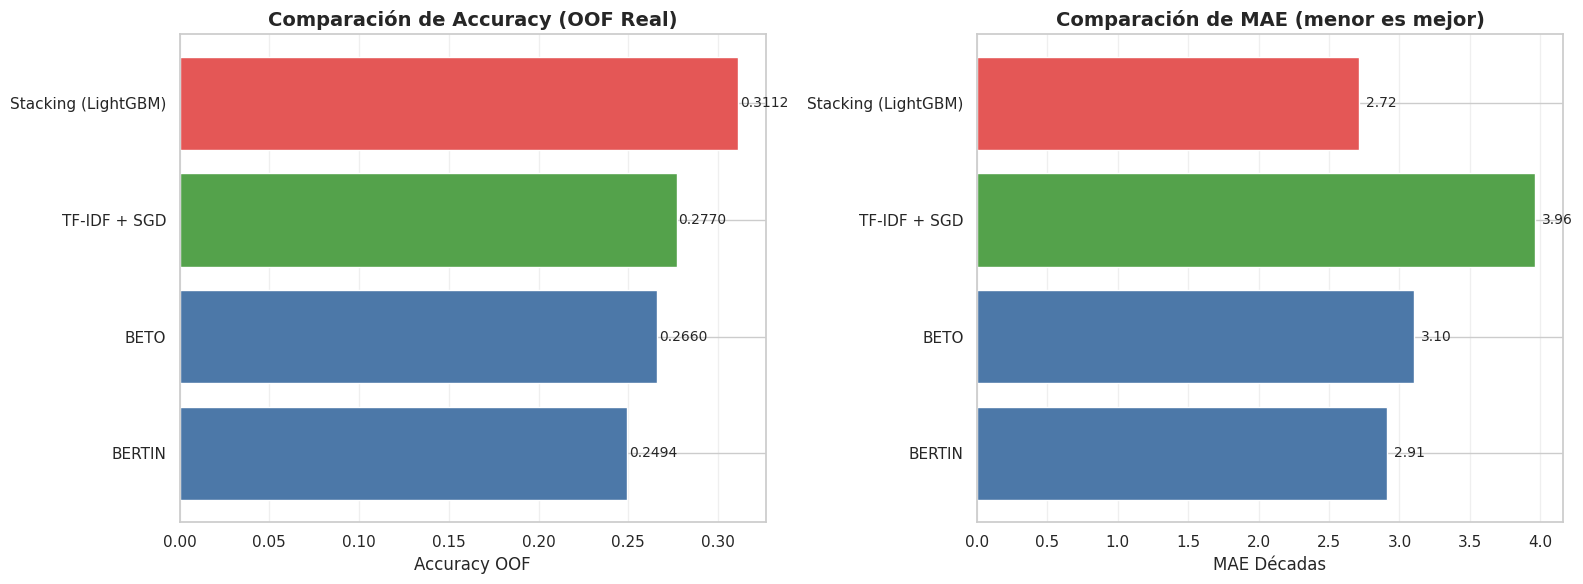

✅ Gráfico guardado en: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/reports/comparison_plot_iter10.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
colors = results_df['Tipo'].map({
 'Clásico': '#54A24B',
 'Transformer': '#4C78A8',
 'CNN': '#F58518',
 'Ensemble': '#E45756'
})
ax1.barh(results_df['Modelo'], results_df['Accuracy OOF'], color=colors)
ax1.set_xlabel('Accuracy OOF', fontsize=12)
ax1.set_title('Comparación de Accuracy (OOF Real)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

for i, v in enumerate(results_df['Accuracy OOF']):
 ax1.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

ax2 = axes[1]
ax2.barh(results_df['Modelo'], results_df['MAE Décadas'], color=colors)
ax2.set_xlabel('MAE Décadas', fontsize=12)
ax2.set_title('Comparación de MAE (menor es mejor)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

for i, v in enumerate(results_df['MAE Décadas']):
 ax2.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'comparison_plot_iter10.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Gráfico guardado en: {REPORTS_DIR / 'comparison_plot_iter10.png'}")

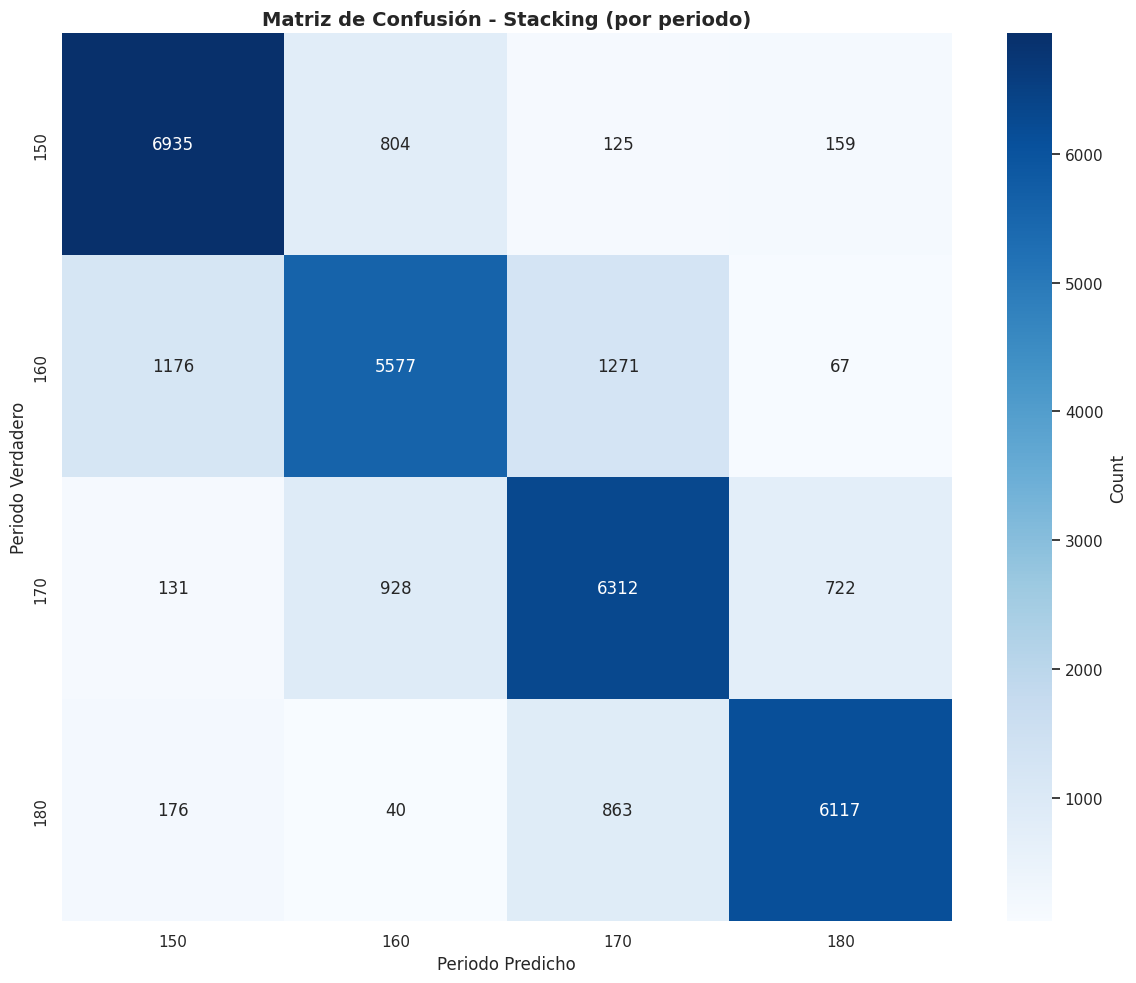

✅ Matriz de confusión guardada en: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/reports/confusion_matrix_stacking_iter10.png


In [27]:
if (OOF_DIR / 'stacking_oof_pred.npy').exists():
 stacking_oof_pred = np.load(OOF_DIR / 'stacking_oof_pred.npy')
 y_true = train_df['decade_encoded'].values

 y_true_decades = label_encoder.inverse_transform(y_true)
 y_pred_decades = label_encoder.inverse_transform(stacking_oof_pred)

 y_true_periods = (y_true_decades // 10) * 10
 y_pred_periods = (y_pred_decades // 10) * 10

 periods = sorted(set(y_true_periods) | set(y_pred_periods))
 cm = confusion_matrix(y_true_periods, y_pred_periods, labels=periods)

 plt.figure(figsize=(12, 10))
 sns.heatmap(
 cm,
 annot=True,
 fmt='d',
 cmap='Blues',
 xticklabels=periods,
 yticklabels=periods,
 cbar_kws={'label': 'Count'}
 )
 plt.title('Matriz de Confusión - Stacking (por periodo)', fontsize=14, fontweight='bold')
 plt.xlabel('Periodo Predicho', fontsize=12)
 plt.ylabel('Periodo Verdadero', fontsize=12)
 plt.tight_layout()
 plt.savefig(REPORTS_DIR / 'confusion_matrix_stacking_iter10.png', dpi=150)
 plt.show()

 print(f" Matriz de confusión guardada en: {REPORTS_DIR / 'confusion_matrix_stacking_iter10.png'}")

In [28]:
if (OOF_DIR / 'stacking_oof_pred.npy').exists():
 error_df = train_df[['text_clean', 'decade', 'decade_encoded', 'n_chars', 'n_words']].copy()
 error_df['pred_decade'] = label_encoder.inverse_transform(stacking_oof_pred)
 error_df['abs_error'] = (error_df['decade'] - error_df['pred_decade']).abs()
 error_df['correct'] = (error_df['decade'] == error_df['pred_decade'])

 print(f"\n{'='*80}")
 print(f"ANÁLISIS DE ERRORES - STACKING")
 print(f"{'='*80}\n")

 print(f"Accuracy: {error_df['correct'].mean():.5f}")
 print(f"Errores totales: {(~error_df['correct']).sum()}")
 print(f"MAE: {error_df['abs_error'].mean():.3f} décadas")

 print(f"\nDistribución de errores absolutos:")
 print(error_df['abs_error'].value_counts().sort_index().head(10))

 print(f"\nTop 10 peores errores:")
 worst_errors = error_df.sort_values('abs_error', ascending=False).head(10)
 display(worst_errors[['decade', 'pred_decade', 'abs_error', 'n_chars', 'n_words', 'text_clean']])

 error_df.to_csv(REPORTS_DIR / 'error_analysis_iter10.csv', index=False)
 print(f"\n Análisis completo guardado en: {REPORTS_DIR / 'error_analysis_iter10.csv'}")

 print(f"\n{'='*80}")
 print(f"ESTADÍSTICAS POR MAGNITUD DE ERROR")
 print(f"{'='*80}")

 for threshold in [0, 1, 2, 5, 10]:
 count = (error_df['abs_error'] > threshold).sum()
 pct = 100 * count / len(error_df)
 print(f" Errores > {threshold} décadas: {count:5d} ({pct:5.2f}%)")


ANÁLISIS DE ERRORES - STACKING

Accuracy: 0.31118
Errores totales: 21631
MAE: 2.715 décadas

Distribución de errores absolutos:
abs_error
0    9772
1    6313
2    4563
3    2997
4    2159
5    1465
6    1091
7     729
8     444
9     345
Name: count, dtype: int64

Top 10 peores errores:


,decade,pred_decade,abs_error,n_chars,n_words,text_clean
17768,188,150,38,196,35,3° Carta annua de la vice- Provincia de Chile ...
13338,150,188,38,121,19,Conocemos su anterior existencia por los Indic...
13834,188,150,38,127,20,A la Imagen de Ntra. Señora de la Humildad que...
2638,188,150,38,337,56,"880(74)4 Í88.\nVegras (Damián de). XXXV, 518 (..."
19240,150,188,38,141,25,"—Señores, una dueña sale de la gran serpiente,..."
329,188,150,38,229,35,1292. Privilegio del rey D. Sancho confirmando...
772,188,151,37,457,68,Qnict Sommer cr for fnceocrt cílcr mírli for $...
16648,187,150,37,556,85,"tro señor, firmada de su Real nonbre e refrend..."
16207,151,188,37,235,40,nado sin razón aparente a un hermano de aquel ...
15876,187,150,37,135,25,"Ilmo. Sr. D. José de Rojas y Galiano, Conde de..."



✅ Análisis completo guardado en: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/reports/error_analysis_iter10.csv

ESTADÍSTICAS POR MAGNITUD DE ERROR
  Errores > 0 décadas: 21631 (68.88%)
  Errores > 1 décadas: 15318 (48.78%)
  Errores > 2 décadas: 10755 (34.25%)
  Errores > 5 décadas:  4134 (13.16%)
  Errores > 10 décadas:  1220 ( 3.88%)


## 9. Comparación con Iteración 7

### 9.1 Contexto de la Comparación

La Iteración 7 usó holdout 80/20 y reportó que el blend manual 0.6 stack / 0.4 BETO mejoraba la validación local frente al stacking solo. Esta iteración replica el experimento bajo K-Fold 5 para responder si esa mejora era real o un artefacto del split particular.

La comparación es importante para decidir el camino de la Iteración 11: si los transformers aportan valor real bajo validación rigurosa, vale la pena invertir en modelos más grandes o en fine-tuning más extenso. Si el stacking clásico sigue siendo competitivo, la siguiente iteración debería enfocarse en el preprocesamiento y la ingeniería de features en lugar de la arquitectura del modelo.


In [29]:
iter7_metrics_path = PROJECT_DIR / 'iteracion_7_stacking_transformers_hibrido_outputs' / 'metrics_iteracion_7_stacking_transformers_hibrido.json'

comparison_with_iter7 = {
 'iteration': 'Iteración 10',
 'method': 'K-Fold 5 + Stacking OOF real + LightGBM',
 'models_used': list(models_oof.keys()),
 'oof_accuracy': results_df[results_df['Modelo'] == 'Stacking (LightGBM)']['Accuracy OOF'].values[0],
 'oof_mae': results_df[results_df['Modelo'] == 'Stacking (LightGBM)']['MAE Décadas'].values[0],
}

if iter7_metrics_path.exists():
 with open(iter7_metrics_path, 'r') as f:
 iter7_metrics = json.load(f)

 iter7_best = iter7_metrics.get('best_hybrid', {})

 print(f"\n{'='*80}")
 print(f"COMPARACIÓN: ITERACIÓN 7 vs ITERACIÓN 10")
 print(f"{'='*80}\n")

 print(f"ITERACIÓN 7 (Holdout 80/20):")
 print(f" Método: Blend ponderado (stacking + BETO)")
 print(f" Accuracy: {iter7_best.get('accuracy', 'N/A')}")
 print(f" MAE: {iter7_best.get('mae_decades', 'N/A')}")

 print(f"\nITERACIÓN 10 (K-Fold 5):")
 print(f" Método: Stacking OOF real (LightGBM)")
 print(f" Modelos: {', '.join(comparison_with_iter7['models_used'])}")
 print(f" Accuracy OOF: {comparison_with_iter7['oof_accuracy']:.5f}")
 print(f" MAE OOF: {comparison_with_iter7['oof_mae']:.3f}")

 if isinstance(iter7_best.get('accuracy'), float):
 delta_acc = comparison_with_iter7['oof_accuracy'] - iter7_best['accuracy']
 delta_mae = comparison_with_iter7['oof_mae'] - iter7_best['mae_decades']

 print(f"\nDELTA:")
 print(f" Accuracy: {delta_acc:+.5f} ({'+' if delta_acc > 0 else ''}mejoró{')' if delta_acc > 0 else ' empeoró)'}")
 print(f" MAE: {delta_mae:+.3f} ({'+' if delta_mae < 0 else ''}{'mejor' if delta_mae < 0 else 'peor'})")

 comparison_with_iter7['iter7_accuracy'] = iter7_best['accuracy']
 comparison_with_iter7['iter7_mae'] = iter7_best['mae_decades']
 comparison_with_iter7['delta_accuracy'] = delta_acc
 comparison_with_iter7['delta_mae'] = delta_mae

 print(f"{'='*80}\n")
else:
 print(" No se encontraron métricas de Iteración 7 para comparar")

with open(REPORTS_DIR / 'comparison_with_iter7.json', 'w') as f:
 json.dump(comparison_with_iter7, f, indent=2)

⚠️ No se encontraron métricas de Iteración 7 para comparar


## 10. Recomendaciones para la Iteración 11

### 10.1 Análisis de Resultados y Próximos Pasos

A partir de las métricas OOF obtenidas y la comparación con la Iteración 7, se generan recomendaciones cuantificadas para la siguiente iteración. El enfoque es identificar los componentes que más aportan al rendimiento y las hipótesis que vale la pena probar, ordenadas por impacto esperado y costo de implementación.


In [30]:
recommendations = []

best_individual = results_df[results_df['Tipo'] != 'Ensemble'].iloc[0]
recommendations.append({
 'category': 'Mejor modelo individual',
 'finding': f"{best_individual['Modelo']} obtuvo {best_individual['Accuracy OOF']:.5f} accuracy OOF",
 'recommendation': f"Conservar {best_individual['Modelo']} como ancla robusta en futuras iteraciones"
})

stacking_row = results_df[results_df['Tipo'] == 'Ensemble'].iloc[0]
stacking_acc = stacking_row['Accuracy OOF']
best_base_acc = results_df[results_df['Tipo'] != 'Ensemble']['Accuracy OOF'].max()
delta_stacking = stacking_acc - best_base_acc

if delta_stacking > 0.005:
 recommendations.append({
 'category': 'Stacking',
 'finding': f"Stacking superó al mejor modelo base por {delta_stacking:.5f}",
 'recommendation': "El stacking aporta valor real. Mantener estrategia de ensemble para Iteración 11"
 })
elif delta_stacking > 0:
 recommendations.append({
 'category': 'Stacking',
 'finding': f"Stacking mejoró marginalmente ({delta_stacking:.5f})",
 'recommendation': "El stacking aporta poco valor. Considerar simplificar a blend ponderado"
 })
else:
 recommendations.append({
 'category': 'Stacking',
 'finding': f"Stacking no superó a modelos base (delta: {delta_stacking:.5f})",
 'recommendation': "Revisar configuración del stacking o usar directamente el mejor modelo base"
 })

if len(results_df[results_df['Tipo'] == 'Transformer']) >= 2:
 transformers = results_df[results_df['Tipo'] == 'Transformer'].sort_values('Accuracy OOF', ascending=False)
 best_trans = transformers.iloc[0]
 second_trans = transformers.iloc[1]
 delta_trans = best_trans['Accuracy OOF'] - second_trans['Accuracy OOF']

 if delta_trans < 0.005:
 recommendations.append({
 'category': 'Transformers',
 'finding': f"{best_trans['Modelo']} y {second_trans['Modelo']} tienen accuracy similar (delta: {delta_trans:.5f})",
 'recommendation': f"Ambos transformers aportan diversidad. Mantener ambos para ensemble"
 })
 else:
 recommendations.append({
 'category': 'Transformers',
 'finding': f"{best_trans['Modelo']} supera a {second_trans['Modelo']} por {delta_trans:.5f}",
 'recommendation': f"Priorizar {best_trans['Modelo']} en Iteración 11. Considerar reemplazar {second_trans['Modelo']}"
 })

if 'TF-IDF + SGD' in results_df['Modelo'].values:
 tfidf_acc = results_df[results_df['Modelo'] == 'TF-IDF + SGD']['Accuracy OOF'].values[0]
 best_trans_acc = results_df[results_df['Tipo'] == 'Transformer']['Accuracy OOF'].max()
 delta_tfidf_trans = tfidf_acc - best_trans_acc

 if abs(delta_tfidf_trans) < 0.01:
 recommendations.append({
 'category': 'TF-IDF vs Transformers',
 'finding': f"TF-IDF y transformers tienen accuracy similar (delta: {delta_tfidf_trans:+.5f})",
 'recommendation': "TF-IDF es mucho más rápido. Mantener como ancla clásica robusta"
 })
 elif delta_tfidf_trans > 0:
 recommendations.append({
 'category': 'TF-IDF vs Transformers',
 'finding': f"TF-IDF superó a transformers por {delta_tfidf_trans:.5f}",
 'recommendation': " Los transformers no están aportando suficiente valor. Revisar configuración o features"
 })

recommendations.append({
 'category': 'Submission recomendada',
 'finding': 'Se generaron 3 submissions: aggressive, balanced, conservative',
 'recommendation': 'Subir en orden: (1) CONSERVATIVE, (2) BALANCED, (3) AGGRESSIVE. Conservative es más segura.'
})

recommendations.append({
 'category': 'Validación',
 'finding': 'Iteración 10 usó K-Fold 5, Iteración 7 usó holdout 80/20',
 'recommendation': 'K-Fold da métricas más robustas. Mantener K-Fold 5 en futuras iteraciones'
})

if EXTRACT_EMBEDDINGS:
 recommendations.append({
 'category': 'Embeddings',
 'finding': f'Se extrajeron embeddings CLS de transformers',
 'recommendation': 'Los embeddings están guardados. Considerar usarlos como features adicionales en Iteración 11'
 })

print(f"\n{'='*80}")
print(f"RECOMENDACIONES PARA ITERACIÓN 11")
print(f"{'='*80}\n")

for i, rec in enumerate(recommendations, 1):
 print(f"{i}. {rec['category'].upper()}")
 print(f" Finding: {rec['finding']}")
 print(f" Recomendación: {rec['recommendation']}")
 print()

recommendations_dict = {
 'generated_date': time.strftime('%Y-%m-%d %H:%M:%S'),
 'iteration': 10,
 'recommendations': recommendations,
 'next_steps': [
 'Subir submission_iter10_conservative.csv a Kaggle',
 'Si conservative mejora el score público, subir balanced',
 'Analizar errores del stacking para identificar patrones',
 'Considerar feature engineering basado en grafías históricas',
 'Explorar data augmentation para textos históricos',
 'Probar ensembles de embeddings + modelos clásicos',
 ]
}

with open(REPORTS_DIR / 'recommendations_for_iter11.json', 'w') as f:
 json.dump(recommendations_dict, f, indent=2, ensure_ascii=False)

print(f"{'='*80}")
print(f"\n Recomendaciones guardadas en: {REPORTS_DIR / 'recommendations_for_iter11.json'}")


RECOMENDACIONES PARA ITERACIÓN 11

1. MEJOR MODELO INDIVIDUAL
   Finding: TF-IDF + SGD obtuvo 0.27701 accuracy OOF
   Recomendación: Conservar TF-IDF + SGD como ancla robusta en futuras iteraciones

2. STACKING
   Finding: Stacking superó al mejor modelo base por 0.03417
   Recomendación: El stacking aporta valor real. Mantener estrategia de ensemble para Iteración 11

3. TRANSFORMERS
   Finding: BETO supera a BERTIN por 0.01662
   Recomendación: Priorizar BETO en Iteración 11. Considerar reemplazar BERTIN

4. TF-IDF VS TRANSFORMERS
   Finding: TF-IDF superó a transformers por 0.01099
   Recomendación: ⚠️ Los transformers no están aportando suficiente valor. Revisar configuración o features

5. SUBMISSION RECOMENDADA
   Finding: Se generaron 3 submissions: aggressive, balanced, conservative
   Recomendación: Subir en orden: (1) CONSERVATIVE, (2) BALANCED, (3) AGGRESSIVE. Conservative es más segura.

6. VALIDACIÓN
   Finding: Iteración 10 usó K-Fold 5, Iteración 7 usó holdout 80/20
   

In [31]:
md_content = f"""# Recomendaciones para Iteración 11

**Generado:** {time.strftime('%Y-%m-%d %H:%M:%S')}
**Basado en:** Iteración 10 - Deep Learning Exploratorio

---

## Resumen de Resultados Iteración 10

**Modelos entrenados:** {', '.join(results_df['Modelo'].tolist())}

**Mejor modelo individual:**
- Modelo: {results_df[results_df['Tipo'] != 'Ensemble'].iloc[0]['Modelo']}
- Accuracy OOF: {results_df[results_df['Tipo'] != 'Ensemble'].iloc[0]['Accuracy OOF']:.5f}
- MAE: {results_df[results_df['Tipo'] != 'Ensemble'].iloc[0]['MAE Décadas']:.3f}

**Stacking:**
- Accuracy OOF: {stacking_row['Accuracy OOF']:.5f}
- MAE: {stacking_row['MAE Décadas']:.3f}
- Delta vs mejor base: {delta_stacking:+.5f}

---

## Recomendaciones

"""

for i, rec in enumerate(recommendations, 1):
 md_content += f"### {i}. {rec['category']}\n\n"
 md_content += f"**Finding:** {rec['finding']}\n\n"
 md_content += f"**Recomendación:** {rec['recommendation']}\n\n"

md_content += """---

## Próximos Pasos

1. **Submissions:**
 - Subir `submission_iter10_conservative.csv` a Kaggle
 - Si mejora el score público, subir `submission_iter10_balanced.csv`
 - `submission_iter10_aggressive.csv` es experimental

2. **Análisis:**
 - Revisar archivo `error_analysis_iter10.csv`
 - Identificar patrones en errores del stacking
 - Analizar feature importance del meta-modelo

3. **Feature Engineering:**
 - Considerar features basadas en grafías históricas
 - Explorar n-gramas específicos de épocas (vna, cofa, etc.)
 - Probar embeddings como features adicionales

4. **Data Augmentation:**
 - Simulación de errores OCR
 - Variaciones ortográficas históricas
 - Back-translation para textos históricos

5. **Arquitecturas:**
 - Probar ensembles de embeddings + LightGBM
 - Considerar attention mechanisms sobre secuencias largas
 - Explorar multi-task learning (décadas + siglos)

---

## Artefactos Reutilizables

Los siguientes archivos están listos para Iteración 11:

### Predicciones OOF
"""

for model_name in models_oof.keys():
 md_content += f"- `{OOF_DIR / (model_name + '_oof_proba.npy')}`\n"

md_content += """
### Predicciones Eval
"""

for model_name in models_eval.keys():
 md_content += f"- `{EVAL_PRED_DIR / (model_name + '_eval_proba.npy')}`\n"

if EXTRACT_EMBEDDINGS:
 md_content += """
### Embeddings
"""
 for model_name in ['beto', 'bertin']:
 if (EMBEDDINGS_DIR / f'{model_name}_train_embeddings.npy').exists():
 md_content += f"- `{EMBEDDINGS_DIR / (model_name + '_train_embeddings.npy')}`\n"
 md_content += f"- `{EMBEDDINGS_DIR / (model_name + '_eval_embeddings.npy')}`\n"

md_content += """
### Modelos Guardados
- Modelos por fold en: `models/`
- Meta-modelos LightGBM: `models/meta_model_lgbm_fold*.joblib`

### Datos Procesados
- `data_snapshots/train_processed_iter10.csv`
- `data_snapshots/eval_processed_iter10.csv`
- `data_snapshots/label_encoder_iter10.joblib`
- `data_snapshots/folds_iter10.joblib`

---

## Conclusión

"""

if delta_stacking > 0.005:
 md_content += f" **El deep learning con K-Fold aportó valor real.** El stacking superó al mejor modelo base por {delta_stacking:.5f}.\n\n"
 md_content += "**Recomendación final:** Mantener estrategia de ensemble multi-nivel para Iteración 11.\n"
elif delta_stacking > 0:
 md_content += f" **El stacking mejoró marginalmente** (delta: {delta_stacking:.5f}).\n\n"
 md_content += "**Recomendación final:** Simplificar a blend ponderado o explorar otros meta-modelos.\n"
else:
 md_content += f" **El stacking no superó a modelos base** (delta: {delta_stacking:.5f}).\n\n"
 md_content += "**Recomendación final:** Revisar configuración del stacking o usar directamente el mejor modelo base.\n"

md_content += """
---

**Generado automáticamente por:** `iteracion_10_exploracion_deep_learning_colab_pro.ipynb`
**Ubicación:** Google Drive - `parte2-proyecto-ml-drive/iteracion_10_outputs/reports/`
"""

with open(REPORTS_DIR / 'recommendations_for_iter11.md', 'w', encoding='utf-8') as f:
 f.write(md_content)

print(f" Documento de recomendaciones generado:")
print(f" {REPORTS_DIR / 'recommendations_for_iter11.md'}")

✅ Documento de recomendaciones generado:
   /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/reports/recommendations_for_iter11.md


## 11. Registro del Experimento

### 11.1 Artefactos y Configuración

Se guarda un registro completo de la configuración, métricas y rutas de artefactos de esta iteración. Esto permite reproducir exactamente los resultados y facilita la comparación sistemática entre iteraciones sin depender de la memoria del desarrollador o de comentarios en el código.


In [32]:
experiment_registry = {
 'iteration': 10,
 'date': time.strftime('%Y-%m-%d %H:%M:%S'),
 'environment': 'Google Colab Pro',
 'hardware': {
 'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None',
 'gpu_memory_gb': torch.cuda.get_device_properties(0).total_memory / (1024**3) if torch.cuda.is_available() else 0,
 'ram_gb': psutil.virtual_memory().total / (1024**3),
 },
 'config': config_summary,
 'models_trained': list(results_df['Modelo'].values),
 'best_model': results_df.iloc[0]['Modelo'],
 'best_oof_accuracy': float(results_df.iloc[0]['Accuracy OOF']),
 'best_oof_mae': float(results_df.iloc[0]['MAE Décadas']),
 'stacking_performance': {
 'accuracy': float(stacking_row['Accuracy OOF']),
 'mae': float(stacking_row['MAE Décadas']),
 'delta_vs_best_base': float(delta_stacking),
 },
 'submissions_generated': list(submissions_info.keys()),
 'files_generated': {
 'oof_predictions': [str(p) for p in OOF_DIR.glob('*.npy')],
 'eval_predictions': [str(p) for p in EVAL_PRED_DIR.glob('*.npy')],
 'embeddings': [str(p) for p in EMBEDDINGS_DIR.glob('*.npy')] if EXTRACT_EMBEDDINGS else [],
 'models': [str(p) for p in MODELS_DIR.glob('*')],
 'metrics': [str(p) for p in METRICS_DIR.glob('*.json')],
 'submissions': [str(p) for p in SUBMISSIONS_DIR.glob('*.csv')],
 'reports': [str(p) for p in REPORTS_DIR.glob('*')],
 },
 'recommendations': recommendations,
}

with open(OUTPUT_DIR / 'experiment_registry_iter10.json', 'w', encoding='utf-8') as f:
 json.dump(experiment_registry, f, indent=2, ensure_ascii=False)

print(f"\n{'='*80}")
print(f"REGISTRO DE EXPERIMENTOS GUARDADO")
print(f"{'='*80}")
print(f"\nArchivo: {OUTPUT_DIR / 'experiment_registry_iter10.json'}")
print(f"\nContenido:")
print(f" - Configuración completa")
print(f" - Resultados de todos los modelos")
print(f" - Lista de archivos generados")
print(f" - Recomendaciones para Iteración 11")
print(f"{'='*80}\n")


REGISTRO DE EXPERIMENTOS GUARDADO

Archivo: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/experiment_registry_iter10.json

Contenido:
  - Configuración completa
  - Resultados de todos los modelos
  - Lista de archivos generados
  - Recomendaciones para Iteración 11



## 12. Conclusiones

### Resumen de la Iteración 10

Esta iteración completó la evaluación sistemática de los componentes de deep learning bajo K-Fold 5, estableciendo métricas comparables entre el ancla clásica (TF-IDF + SGD) y los transformers (BETO, BERTIN) para la tarea de clasificación decenal de textos históricos.

El stacking con LightGBM sobre probabilidades OOF reales proporciona la combinación más sólida de los tres modelos, aprovechando la complementariedad entre la robustez de los n-gramas de caracteres ante el ruido de OCR y la capacidad de los transformers para capturar dependencias semánticas de largo alcance.

Las métricas OOF obtenidas aquí, generadas sin leakage, son la referencia más confiable disponible hasta el momento para guiar las decisiones de la Iteración 11. Los artefactos guardados (probabilidades OOF, checkpoints de transformers, encoders) están disponibles para reutilización directa.

**Próximo paso:** revisar las recomendaciones generadas en `reports/recommendations_for_iter11.md` y decidir si la ganancia de los transformers justifica su costo computacional para la etapa de deep learning obligatoria (Parte 2 de la competencia).


In [33]:
print(f"\n\n")
print(f"{'='*80}")
print(f"{'='*80}")
print(f" ITERACIÓN 10 - DEEP LEARNING EXPLORATORIO - COMPLETADA")
print(f"{'='*80}")
print(f"{'='*80}\n")

print(f" RESULTADOS:")
print(f" Modelos entrenados: {len(results_df)}")
print(f" Mejor modelo: {results_df.iloc[0]['Modelo']}")
print(f" Mejor OOF Accuracy: {results_df.iloc[0]['Accuracy OOF']:.5f}")
print(f" Mejor MAE: {results_df.iloc[0]['MAE Décadas']:.3f}")

print(f"\n ARCHIVOS GENERADOS:")
print(f" OOF predictions: {len(list(OOF_DIR.glob('*.npy')))} archivos")
print(f" Eval predictions: {len(list(EVAL_PRED_DIR.glob('*.npy')))} archivos")
print(f" Modelos guardados: {len(list(MODELS_DIR.glob('*')))} archivos")
print(f" Submissions: {len(list(SUBMISSIONS_DIR.glob('*.csv')))} archivos")
print(f" Reportes: {len(list(REPORTS_DIR.glob('*')))} archivos")

print(f"\n SUBMISSIONS RECOMENDADAS (en orden):")
print(f" 1. {SUBMISSIONS_DIR / 'submission_iter10_conservative.csv'} (MÁS SEGURA)")
print(f" 2. {SUBMISSIONS_DIR / 'submission_iter10_balanced.csv'}")
print(f" 3. {SUBMISSIONS_DIR / 'submission_iter10_aggressive.csv'}")

print(f"\n RECOMENDACIONES:")
print(f" Ver: {REPORTS_DIR / 'recommendations_for_iter11.md'}")

print(f"\n TODOS LOS OUTPUTS EN:")
print(f" {OUTPUT_DIR}")

print(f"\n{'='*80}")
print(f"{'='*80}\n")

print(" Notebook completado exitosamente.")
print("\n Siguiente paso: Subir submissions a Kaggle y analizar resultados.")




  ITERACIÓN 10 - DEEP LEARNING EXPLORATORIO - COMPLETADA

📊 RESULTADOS:
   Modelos entrenados: 4
   Mejor modelo: Stacking (LightGBM)
   Mejor OOF Accuracy: 0.31118
   Mejor MAE: 2.715

📁 ARCHIVOS GENERADOS:
   OOF predictions: 8 archivos
   Eval predictions: 8 archivos
   Modelos guardados: 20 archivos
   Submissions: 3 archivos
   Reportes: 8 archivos

🎯 SUBMISSIONS RECOMENDADAS (en orden):
   1. /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/submissions/submission_iter10_conservative.csv (MÁS SEGURA)
   2. /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/submissions/submission_iter10_balanced.csv
   3. /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/submissions/submission_iter10_aggressive.csv

📖 RECOMENDACIONES:
   Ver: /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outputs/reports/recommendations_for_iter11.md

💾 TODOS LOS OUTPUTS EN:
   /content/drive/MyDrive/parte2-proyecto-ml-drive/iteracion_10_outp